# 👁️ OpenCV — Classic Computer Vision, From Pixels to Pipelines

> **What you'll learn:** how images are stored as NumPy arrays, how to read/write images and video, color spaces, geometric and perspective transforms, convolution and filtering, gradients and edges, thresholding, morphology, contours, histograms, template matching with non-maximum suppression, feature matching with RANSAC homographies — and how to evaluate a vision pipeline honestly against ground truth.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🔴 Advanced |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [NumPy](../01_Core_Scientific_Computing/01_NumPy.ipynb) (arrays, slicing, broadcasting, dtypes) · [Matplotlib & Seaborn](../02_Data_Visualization/01_Matplotlib_and_Seaborn.ipynb) (showing images and plots) |
| **Tested with** | Python 3.12 · opencv-python-headless 5.0 · numpy 2.5 · scipy 1.18 · pandas 3.0 · matplotlib 3.11 · scikit-learn 1.9 (sample image only) |
| **Interview relevance** | ⭐⭐ Medium–High — convolution and filters, Sobel/Canny, Otsu, homography + RANSAC, IoU and NMS, BGR vs RGB bugs, "when would you *not* use deep learning?" |

## 🤔 What Is OpenCV?

To a computer, a photo is not "a cat on a sofa". It is a **big grid of numbers** — one number per pixel for a grayscale image, or three numbers per pixel (blue, green, red) for a color image.

**OpenCV** (Open Source Computer Vision Library) is a fast C++ library, with Python bindings, containing thousands of ready-made algorithms that turn those grids of numbers into useful answers: *Where are the edges? Which pixels are orange? Where is this book in that photo? How many objects are on the table?*

Think of it as a **photo lab full of specialised tools**: a blur brush, an edge highlighter, a stencil cutter (thresholding), a ruler for shapes (contours), and a matching game that finds the same object in two photos (feature matching). You combine these tools into a **pipeline** — a fixed sequence of steps that turns an image into an answer.

```
  image (H×W×3 uint8) ─► color convert ─► blur ─► threshold / edges ─► contours ─► measurements ─► answer
                           "grayscale"    "denoise"  "which pixels matter"  "shapes"   "area, center"   "7 candies"
```

This is called **classic computer vision**: every step is a hand-designed rule, not something learned from data. Deep learning (next notebook) *learns* the rules instead — but it is built on the same ideas (convolution!), and classic tools are still everywhere around it.

## 🎯 Why It Matters

- **Every vision system uses it somewhere.** Loading, resizing, color conversion, and augmenting images before a neural network; drawing boxes and applying NMS after it; calibrating cameras; rectifying documents; stitching panoramas.
- **It is often the right answer on its own.** Factory lines with fixed lighting, barcode/document scanners, measuring parts, counting objects on a conveyor, motion detection on a CPU-only camera — no training data, millisecond latency, fully explainable.
- **Convolution is the core idea of CNNs.** If you understand a Sobel filter, you understand what the first layer of a CNN learns.
- **In interviews** you will be asked to explain convolution and edge detection, implement IoU and non-maximum suppression, reason about homographies and RANSAC, debug BGR/RGB and `uint8` overflow bugs, and argue *when classic CV beats deep learning*. This notebook practises exactly that, on real images.

## ✅ By the End You Can

- [ ] Explain how images are stored (`H×W×C`, `uint8`, BGR) and avoid the classic BGR/RGB, `(x, y)` vs `[row, col]`, and overflow bugs
- [ ] Apply and choose between box, Gaussian, median, and bilateral filters, and implement 2-D convolution from scratch
- [ ] Compute Sobel gradients correctly, run Canny with sensible thresholds, and threshold with Otsu or adaptive methods
- [ ] Use morphology and contours to find, measure, and count objects
- [ ] Rectify a perspective-distorted document and localise an object with ORB + ratio test + RANSAC homography
- [ ] Evaluate a detector honestly with matched precision/recall against ground truth, including held-out stress tests

## 📋 Table of Contents

1. [Images Are NumPy Arrays](#1.-Images-Are-NumPy-Arrays-🟢)
2. [Reading and Writing Images](#2.-Reading-and-Writing-Images-🟢)
3. [Color Spaces and HSV Thresholding](#3.-Color-Spaces-and-HSV-Thresholding-🟢)
4. [Geometric Transforms: Resize, Rotate, Affine, Perspective](#4.-Geometric-Transforms:-Resize,-Rotate,-Affine,-Perspective-🟡)
5. [Convolution and Filtering](#5.-Convolution-and-Filtering-🟡)
6. [Image Gradients and Edges](#6.-Image-Gradients-and-Edges-🟡)
7. [Thresholding: Global, Otsu, Adaptive](#7.-Thresholding:-Global,-Otsu,-Adaptive-🟢)
8. [Morphology](#8.-Morphology-🟢)
9. [Contours and Shape Features](#9.-Contours-and-Shape-Features-🟡)
10. [Histograms and CLAHE](#10.-Histograms-and-CLAHE-🟡)
11. [Template Matching with Non-Maximum Suppression](#11.-Template-Matching-with-Non-Maximum-Suppression-🟡)
12. [Feature Matching: ORB, Ratio Test, RANSAC Homography](#12.-Feature-Matching:-ORB,-Ratio-Test,-RANSAC-Homography-🔴)
13. [Reading Frames From a Real Video](#13.-Reading-Frames-From-a-Real-Video-🟢)
14. [Classic CV vs Deep Learning](#14.-Classic-CV-vs-Deep-Learning-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Counting-Candies-With-an-Honest-Evaluation) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

- We install **`opencv-python-headless`**: the same library without GUI windows. `cv2.imshow` does not work inside Jupyter anyway, so we display images with Matplotlib via the `show()` helper.
- The notebook downloads **real sample files from OpenCV's own GitHub repository** (about 8.6 MB in total, mostly one short video) and caches them in `_outputs/opencv_samples/`. It also uses a photo that ships with scikit-learn.
- The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "opencv-python-headless>=4.10" "numpy>=2.0" "scipy>=1.11" "pandas>=2.2" matplotlib scikit-learn

import sys
import time
import urllib.request
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import scipy.ndimage as ndi
import sklearn
from numpy.lib.stride_tricks import sliding_window_view
from scipy.optimize import linear_sum_assignment
from sklearn.datasets import load_sample_image

print(f"Python {sys.version.split()[0]} | OpenCV {cv2.__version__} | NumPy {np.__version__} | "
      f"SciPy {scipy.__version__} | pandas {pd.__version__} | scikit-learn {sklearn.__version__}")

SEED = 42
rng = np.random.default_rng(SEED)
cv2.setRNGSeed(SEED)                         # OpenCV's own RNG (used by RANSAC) — reproducible runs
np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.precision", 3)

OUTPUT_DIR = Path("_outputs")                # files we write go here (ignored by git)
DATA_DIR = OUTPUT_DIR / "opencv_samples"
DATA_DIR.mkdir(parents=True, exist_ok=True)
SAMPLE_URL = "https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/"


def fetch(name):
    """Download one of OpenCV's sample files once; afterwards reuse the cached copy."""
    path = DATA_DIR / name
    if not path.exists():
        print(f"downloading {name} …")
        urllib.request.urlretrieve(SAMPLE_URL + name, path)
    return path


for name in ["smarties.png", "sudoku.png", "box.png", "box_in_scene.png", "vtest.avi"]:
    print(f"  {name:17s} {fetch(name).stat().st_size / 1e3:8.1f} kB")


def show(images, titles=None, cols=None, size=3.5):
    """Show images side by side. 3-channel images are assumed to be BGR (OpenCV's order) and converted to RGB."""
    if not isinstance(images, (list, tuple)):
        images, titles = [images], [titles]
    titles = titles or [None] * len(images)
    cols = cols or len(images)
    rows = int(np.ceil(len(images) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(size * cols, size * rows), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, img, title in zip(axes.ravel(), images, titles):
        if img.ndim == 3:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        elif img.dtype == np.uint8:
            ax.imshow(img, cmap="gray", vmin=0, vmax=255)
        else:
            ax.imshow(img, cmap="gray")          # float images (e.g. gradients) are auto-scaled
        if title:
            ax.set_title(title, fontsize=10)
    plt.tight_layout()
    plt.show()


def check(name, got, expected, hint="", atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return

    def close(a, b):
        if isinstance(b, (str, bool, set)) or isinstance(a, (str, bool, set)):
            return a == b
        a_arr, b_arr = np.asarray(a), np.asarray(b)
        if a_arr.shape != b_arr.shape:
            return False
        if np.issubdtype(b_arr.dtype, np.number) and np.issubdtype(a_arr.dtype, np.number):
            return bool(np.allclose(a_arr.astype(np.float64), b_arr.astype(np.float64), atol=atol, rtol=0))
        return bool(np.array_equal(a_arr, b_arr))

    shown = got if np.size(got) <= 12 else f"array with shape {np.shape(got)}"
    assert close(got, expected), f"❌ {name}: not quite (got {shown!r}). {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | OpenCV 5.0.0 | NumPy 2.5.3 | SciPy 1.18.1 | pandas 3.0.5 | scikit-learn 1.9.1
  smarties.png          90.8 kB
  sudoku.png           250.7 kB
  box.png               50.7 kB
  box_in_scene.png     122.5 kB
  vtest.avi           8131.7 kB


## 1. Images Are NumPy Arrays 🟢

In OpenCV's Python API **an image is just a NumPy array**:

| Image kind | Shape | dtype | Values |
|---|---|---|---|
| Grayscale | `(H, W)` — height (rows), width (columns) | `uint8` | 0 (black) … 255 (white) |
| Color | `(H, W, 3)` — the last axis holds 3 **channels** | `uint8` | per channel 0 … 255 |

Two rules to tattoo on your arm:

1. **Indexing is `img[row, col]` = `img[y, x]`** — rows first. (But OpenCV *functions* take points as `(x, y)`. More on that in the pitfalls.)
2. **OpenCV stores color as B, G, R** — blue first. Almost everything else (Matplotlib, PIL, scikit-learn, PyTorch models) expects **R, G, B**. OpenCV picked BGR in its early days because common camera and Windows bitmap formats of the time stored bytes in that order, and it never changed.

```
  img[y, x]     →  [B, G, R]          img.shape → (H, W, 3)
       ▲  ▲
      row col
```

In [2]:
china_rgb = load_sample_image("china.jpg")           # scikit-learn returns RGB order
china = cv2.cvtColor(china_rgb, cv2.COLOR_RGB2BGR)  # convert once: every color image in this notebook is BGR
smarties = cv2.imread(str(fetch("smarties.png")))   # cv2.imread always returns BGR

for name, img in [("china", china), ("smarties", smarties)]:
    h, w, c = img.shape
    print(f"{name:8s} shape={img.shape} → H={h}, W={w}, C={c} | dtype={img.dtype} | "
          f"range [{img.min()}, {img.max()}] | {img.nbytes / 1e3:.0f} kB in memory")

row, col = 229, 33                                   # a red candy: row (y) first, then column (x)
print("\nsmarties[229, 33] → B, G, R =", smarties[row, col])
print("mean of each channel (B, G, R):", smarties.reshape(-1, 3).mean(axis=0).round(1))

crop = smarties[180:356, 0:200]                     # slicing = cropping, and it is a VIEW (no copy)
print("crop shape:", crop.shape, "| shares memory with the full image:", np.shares_memory(crop, smarties))

china    shape=(427, 640, 3) → H=427, W=640, C=3 | dtype=uint8 | range [0, 255] | 820 kB in memory
smarties shape=(356, 413, 3) → H=356, W=413, C=3 | dtype=uint8 | range [0, 255] | 441 kB in memory

smarties[229, 33] → B, G, R = [  0   0 240]
mean of each channel (B, G, R): [219.1 220.4 228.9]
crop shape: (176, 200, 3) | shares memory with the full image: True


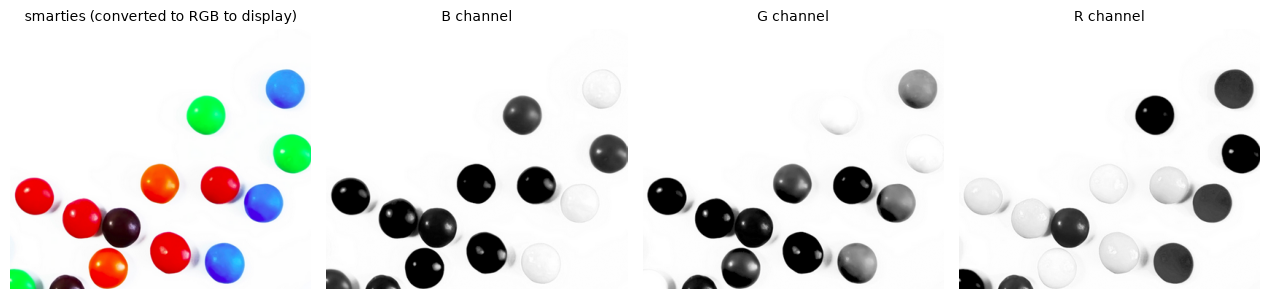

In [3]:
blue_ch, green_ch, red_ch = cv2.split(smarties)     # same as smarties[..., 0], [..., 1], [..., 2]
show([smarties, blue_ch, green_ch, red_ch],
     ["smarties (converted to RGB to display)", "B channel", "G channel", "R channel"], cols=4, size=3.2)

Red candies are **bright in the R channel** and dark in B and G. The white background is bright in all three (white = lots of every color). Blue candies are bright in B and medium in G, because they are a light, slightly cyan blue.

### ✍️ Your Turn

The pixel at **row 229, column 33** of `smarties` belongs to a red candy. Use `np.argmax` to store in `brightest_channel` the **index (0, 1, or 2) of its largest channel**. Before running: which index do you expect, given that OpenCV uses BGR?

In [4]:
brightest_channel = None  # TODO: your code here
check("brightest_channel", brightest_channel, 2, hint="Index smarties[229, 33] to get the 3 channel values, then np.argmax.")

⏳ brightest_channel: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
brightest_channel = int(np.argmax(smarties[229, 33]))
check("brightest_channel", brightest_channel, 2)
```

Index **2** is the *red* channel because the order is B (0), G (1), R (2). In an RGB array, red would be index 0 — this is exactly the confusion behind many "my model sees blue apples" bugs.
</details>

> 💡 **Interview angle:** "What does `img.shape == (480, 640, 3)` mean?" — 480 rows (height), 640 columns (width), 3 channels, and in OpenCV those channels are **BGR**. Mention that a 1080p RGB frame is 1920×1080×3 ≈ 6.2 MB as `uint8`, and 4× that as `float32` — why preprocessing pipelines keep images `uint8` as long as possible.

## 2. Reading and Writing Images 🟢

| Call | What it does |
|---|---|
| `cv2.imread(path, flag)` | Decode a file into an array. `IMREAD_COLOR` (default) → 3-channel BGR, `IMREAD_GRAYSCALE` → 1 channel, `IMREAD_UNCHANGED` → keep the file's channels (e.g. alpha). **Returns `None` instead of raising if the file can't be read.** |
| `cv2.imwrite(path, img, params)` | Encode and save; the format comes from the extension. Returns `True`/`False`. |
| `cv2.imencode(".jpg", img)` / `cv2.imdecode(buf, flag)` | Same, but in memory — what you use in a web API that receives image bytes. |

**PNG** is *lossless* (you get back exactly the same pixels). **JPEG** is *lossy*: it throws away detail your eye barely notices, controlled by a quality setting. We measure the damage with **PSNR** (peak signal-to-noise ratio, in decibels): $\text{PSNR} = 10 \log_{10}\frac{255^2}{\text{MSE}}$. Higher is better; above ~40 dB is visually near-identical.

In [5]:
box_path = fetch("box.png")                        # this PNG is stored as grayscale on disk
for flag in ["IMREAD_COLOR", "IMREAD_GRAYSCALE", "IMREAD_UNCHANGED"]:
    print(f"{flag:17s} → shape {cv2.imread(str(box_path), getattr(cv2, flag)).shape}")

rows = []
ok, png_bytes = cv2.imencode(".png", smarties)
rows.append({"format": "PNG", "size_kB": png_bytes.nbytes / 1e3,
             "identical_pixels": np.array_equal(cv2.imdecode(png_bytes, cv2.IMREAD_COLOR), smarties), "PSNR_dB": np.nan})
for quality in (95, 50, 15):
    ok, jpg_bytes = cv2.imencode(".jpg", smarties, [cv2.IMWRITE_JPEG_QUALITY, quality])
    decoded = cv2.imdecode(jpg_bytes, cv2.IMREAD_COLOR)
    rows.append({"format": f"JPEG q={quality}", "size_kB": jpg_bytes.nbytes / 1e3,
                 "identical_pixels": np.array_equal(decoded, smarties), "PSNR_dB": cv2.PSNR(smarties, decoded)})
print()
print(pd.DataFrame(rows).to_string(index=False))

out_path = OUTPUT_DIR / "smarties_q50.jpg"
print("\nimwrite returned", cv2.imwrite(str(out_path), smarties, [cv2.IMWRITE_JPEG_QUALITY, 50]),
      "| file on disk:", out_path.stat().st_size, "bytes")

IMREAD_COLOR      → shape (223, 324, 3)
IMREAD_GRAYSCALE  → shape (223, 324)
IMREAD_UNCHANGED  → shape (223, 324)

   format  size_kB  identical_pixels  PSNR_dB
      PNG   97.032              True      NaN
JPEG q=95   28.398             False   38.950
JPEG q=50    9.580             False   33.233
JPEG q=15    5.946             False   29.999

imwrite returned True | file on disk: 9580 bytes


> 💡 **Interview angle:** "Would you store your training images as JPEG?" — usually yes for natural photos (10× smaller), but re-encoding **again** at low quality adds blocky artifacts the model may learn; keep masks, medical, and document images **lossless** (PNG) because every pixel label matters. And always check `imread`'s result for `None`.

## 3. Color Spaces and HSV Thresholding 🟢

A **color space** is a way of describing a color with numbers:

- **BGR** — how much blue, green, red light. Great for screens, bad for "find the orange things", because an orange in shadow and an orange in sunlight have very different B, G, R values.
- **Grayscale** — one brightness number. OpenCV uses the standard luma formula $Y = 0.299R + 0.587G + 0.114B$ (our eyes are most sensitive to green).
- **HSV** — **H**ue (*which* color, a position on the color wheel), **S**aturation (*how vivid*: 0 = gray/white, max = pure color), **V**alue (*how bright*). Lighting mostly changes V, so "orange" stays a narrow band of H.

⚠️ In OpenCV's 8-bit HSV, **H runs 0–179** (degrees ÷ 2, so it fits in a byte); S and V run 0–255. Red sits at both ends of the hue wheel (near 0 *and* near 179).

max |manual formula − cv2.cvtColor| = 0.503 (just rounding)
H range 0–179 | S range 0–255 | V range 14–255


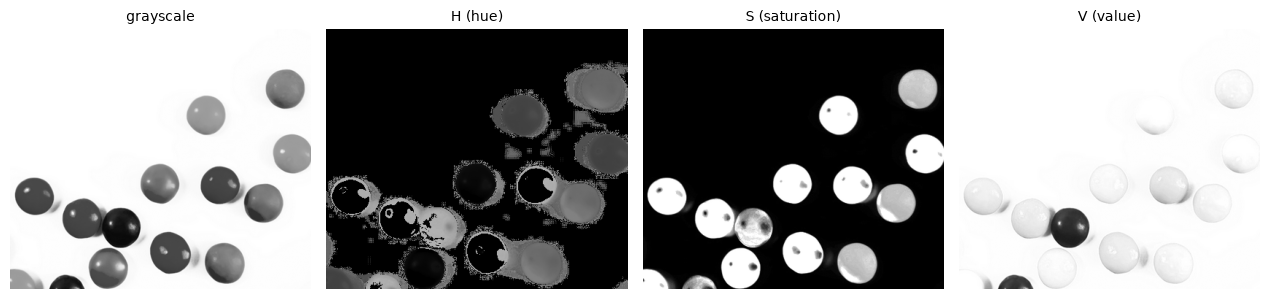

In [6]:
gray = cv2.cvtColor(smarties, cv2.COLOR_BGR2GRAY)
B, G, R = [smarties[..., i].astype(np.float64) for i in range(3)]
manual_gray = 0.299 * R + 0.587 * G + 0.114 * B
print("max |manual formula − cv2.cvtColor| =", round(float(np.abs(manual_gray - gray).max()), 3), "(just rounding)")

hsv = cv2.cvtColor(smarties, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)
print(f"H range {H.min()}–{H.max()} | S range {S.min()}–{S.max()} | V range {V.min()}–{V.max()}")
show([gray, H, S, V], ["grayscale", "H (hue)", "S (saturation)", "V (value)"], cols=4, size=3.2)

Look at the **S channel**: the white background is almost black (unsaturated), and every candy — even the dark brown ones — is bright. Saturation alone separates candies from background; we will use that in the mini project.

Now pick out **blue** candies with `cv2.inRange(hsv, lower, upper)`, which returns 255 where every channel is inside its range, else 0. Then `cv2.connectedComponentsWithStats` labels each separate white blob so we can count them.

blue blobs (area > 500 px): 3 | areas: [2237 2232 2290]
red blobs  (area > 500 px): 5 (by eye there are 4 red candies)
   blob at x=287.4, y=213.5  area=2111
   blob at x= 33.3, y=228.6  area=2091
   blob at x= 98.3, y=259.5  area=2256
   blob at x=218.6, y=306.2  area=2370
   blob at x=128.3, y=341.3  area=700
red blobs with area ≥ 1000 px (at least ~half a candy): 4


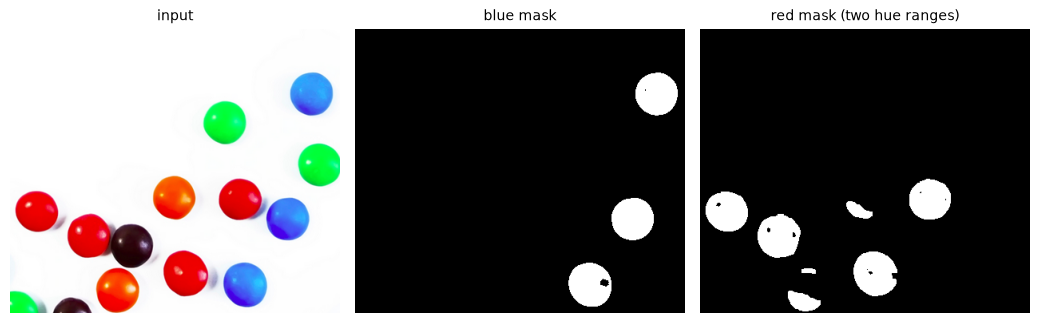

In [7]:
blue_mask = cv2.inRange(hsv, (100, 120, 60), (130, 255, 255))     # H 100–130 ≈ blue; S, V high enough to be a real color
n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(blue_mask)
blue_areas = stats[1:, cv2.CC_STAT_AREA]                           # label 0 is the background
print("blue blobs (area > 500 px):", int((blue_areas > 500).sum()), "| areas:", blue_areas)

# Red wraps around the hue circle, so it needs TWO hue ranges; V > 150 excludes the dark brown candies
red_mask = (((H <= 4) | (H >= 170)) & (S >= 120) & (V >= 150)).astype(np.uint8) * 255
red_mask = cv2.morphologyEx(red_mask, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))   # remove specks (section 8)
n_red, _, red_stats, red_centroids = cv2.connectedComponentsWithStats(red_mask)
red_areas = red_stats[1:, cv2.CC_STAT_AREA]
print("red blobs  (area > 500 px):", int((red_areas > 500).sum()), "(by eye there are 4 red candies)")
for (cx, cy), area in zip(red_centroids[1:], red_areas):
    if area > 500:
        print(f"   blob at x={cx:5.1f}, y={cy:5.1f}  area={area}")
print("red blobs with area ≥ 1000 px (at least ~half a candy):", int((red_areas >= 1000).sum()))
show([smarties, blue_mask, red_mask], ["input", "blue mask", "red mask (two hue ranges)"], size=3.5)

The red mask shows a real weakness of color thresholds: the shaded **lower half of the orange candy** near (135, 327) has a hue close to 0, so it passes as "red" and forms a fifth, smaller blob. Tightening the hue range doesn't remove it (try it); a size rule does, because a full candy covers ~2,000 px. Colors near a category boundary are always fragile — which is why the mini project detects candies by *saturation*, not by one hue.

### ✍️ Your Turn

What hue values does OpenCV give **pure red, pure green, and pure blue**? Build a 1×3 BGR image containing those three colors, convert it to HSV, and store the three **H** values in `hues` (a length-3 array).

In [8]:
hues = None  # TODO: your code here
check("hues", hues, [0, 60, 120], hint="np.uint8([[[0, 0, 255], [0, 255, 0], [255, 0, 0]]]) is a 1×3 BGR image; take [0, :, 0] of the HSV result.")

⏳ hues: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
pure = np.uint8([[[0, 0, 255], [0, 255, 0], [255, 0, 0]]])     # red, green, blue in BGR order
hues = cv2.cvtColor(pure, cv2.COLOR_BGR2HSV)[0, :, 0]
check("hues", hues, [0, 60, 120])
```

On a normal 0–360° color wheel these are 0°, 120°, 240°; OpenCV halves them so they fit in `uint8`. Copying hue thresholds from a website that uses 0–360 is a classic bug.
</details>

> 💡 **Interview angle:** "Why threshold in HSV instead of RGB?" — hue separates *which color* from *how bright*, so one hue range survives shadows and lighting changes; in RGB a shadowed orange changes all three channels. Mention the red wrap-around and OpenCV's 0–179 hue range.

## 4. Geometric Transforms: Resize, Rotate, Affine, Perspective 🟡

Geometric transforms move pixels around. The output pixel at `(x, y)` is looked up at some (usually non-integer) position in the input, so we must **interpolate** — estimate a value between pixels:

| Flag | How it estimates | Use it for |
|---|---|---|
| `INTER_NEAREST` | copy the nearest pixel | label masks (never invent new class ids!) |
| `INTER_LINEAR` (default) | weighted average of 2×2 neighbours | general enlarging, fast |
| `INTER_CUBIC` / `INTER_LANCZOS4` | smooth curve through 4×4 / 8×8 neighbours | high-quality enlarging |
| `INTER_AREA` | average of all input pixels covered by each output pixel | **shrinking** (avoids aliasing) |

**Aliasing** = when you shrink by *skipping* pixels, fine patterns turn into false coarse patterns (the moiré on striped shirts on TV). Below, a *controlled synthetic* example shows it: a pattern of 1-pixel stripes (one white, two black, repeating) whose true average brightness is 85.

In [9]:
stripes = np.zeros((300, 300), np.uint8)
stripes[:, ::3] = 255                                   # true mean brightness = 255 / 3 = 85
print("shrinking a 300×300 stripe pattern to 100×100 (true mean = 85):")
shrink = {}
for name in ["INTER_NEAREST", "INTER_LINEAR", "INTER_AREA"]:
    small = cv2.resize(stripes, (100, 100), interpolation=getattr(cv2, name))
    shrink[name] = abs(float(small.mean()) - 85)
    print(f"  {name:14s} mean={small.mean():6.1f}  std={small.std():5.1f}")
print("closest to the truth:", min(shrink, key=shrink.get))

# Enlarging: shrink the sudoku photo 2× with INTER_AREA, enlarge back with each method, compare to the original
sudoku = cv2.imread(str(fetch("sudoku.png")))
sudoku_gray = cv2.cvtColor(sudoku, cv2.COLOR_BGR2GRAY)
h, w = sudoku_gray.shape
half = cv2.resize(sudoku_gray, (w // 2, h // 2), interpolation=cv2.INTER_AREA)   # dsize is (WIDTH, HEIGHT)!
psnr_up = {}
for name in ["INTER_NEAREST", "INTER_LINEAR", "INTER_CUBIC", "INTER_LANCZOS4"]:
    up = cv2.resize(half, (w, h), interpolation=getattr(cv2, name))
    psnr_up[name] = cv2.PSNR(sudoku_gray, up)
print("\nenlarge-back PSNR (higher = closer to the original):", {k: round(v, 2) for k, v in psnr_up.items()})
print("best for enlarging here:", max(psnr_up, key=psnr_up.get))

shrinking a 300×300 stripe pattern to 100×100 (true mean = 85):
  INTER_NEAREST  mean= 255.0  std=  0.0
  INTER_LINEAR   mean=   0.0  std=  0.0
  INTER_AREA     mean=  85.0  std=  0.0
closest to the truth: INTER_AREA

enlarge-back PSNR (higher = closer to the original): {'INTER_NEAREST': 30.12, 'INTER_LINEAR': 33.68, 'INTER_CUBIC': 36.08, 'INTER_LANCZOS4': 36.48}
best for enlarging here: INTER_LANCZOS4


**Rotation and affine transforms.** An **affine** transform is a 2×3 matrix `M` that maps `(x, y) → M @ [x, y, 1]`. It can rotate, scale, shear, and translate, and it keeps **parallel lines parallel**. `cv2.getRotationMatrix2D(center, angle_degrees, scale)` builds one for rotation; `cv2.warpAffine(img, M, (out_w, out_h))` applies it.

A rotated image needs a bigger canvas or its corners get cut off. The new size is $W' = H|\sin\theta| + W|\cos\theta|$, $H' = H|\cos\theta| + W|\sin\theta|$ — then shift the matrix so the center lands in the middle of the new canvas.

rotation matrix (2×3):
 [[  0.866   0.5   -61.334]
 [ -0.5     0.866 127.097]]
fraction of image kept → same canvas: 84.2% | expanded canvas: 100.0%


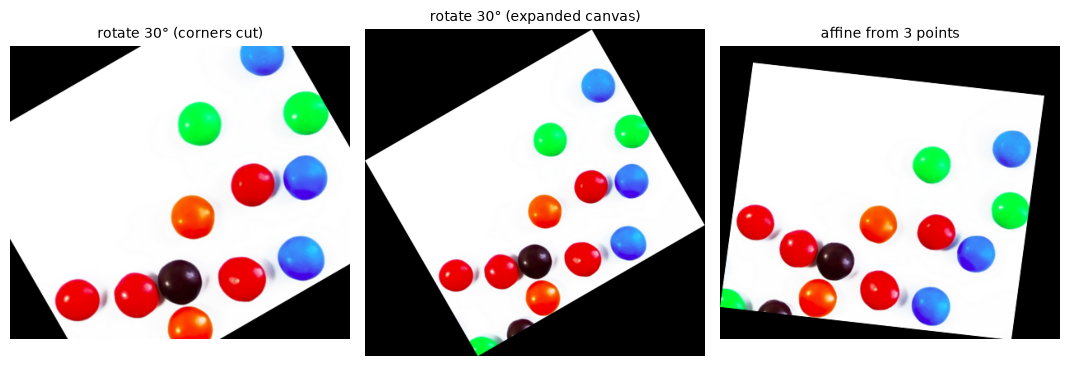

In [10]:
def rotate_keep_all(img, angle):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    cos, sin = abs(M[0, 0]), abs(M[0, 1])
    new_w, new_h = int(round(h * sin + w * cos)), int(round(h * cos + w * sin))
    M[0, 2] += new_w / 2 - w / 2                      # move the rotation center to the new canvas center
    M[1, 2] += new_h / 2 - h / 2
    return cv2.warpAffine(img, M, (new_w, new_h))


h, w = smarties.shape[:2]
M = cv2.getRotationMatrix2D((w / 2, h / 2), 30, 1.0)
print("rotation matrix (2×3):\n", M)
cropped = cv2.warpAffine(smarties, M, (w, h))        # same canvas → corners are lost
expanded = rotate_keep_all(smarties, 30)

white = np.full((h, w), 255, np.uint8)               # rotate an all-white image to measure how much survives
kept_same = cv2.warpAffine(white, M, (w, h)).sum() / white.sum()
kept_expanded = rotate_keep_all(white, 30).sum() / white.sum()
print(f"fraction of image kept → same canvas: {kept_same:.1%} | expanded canvas: {kept_expanded:.1%}")

# Affine from 3 point pairs: where 3 corners should go
src_tri = np.float32([[0, 0], [w - 1, 0], [0, h - 1]])
dst_tri = np.float32([[40, 20], [w - 20, 60], [0, h - 40]])
sheared = cv2.warpAffine(smarties, cv2.getAffineTransform(src_tri, dst_tri), (w, h))
show([cropped, expanded, sheared], ["rotate 30° (corners cut)", "rotate 30° (expanded canvas)", "affine from 3 points"], size=3.6)

**Perspective transforms (homographies).** When you photograph a flat page at an angle, its rectangle becomes a general quadrilateral: parallel lines are *no longer parallel*. An affine matrix cannot undo that; you need a 3×3 **homography** `H` with 8 degrees of freedom:

$$\begin{bmatrix} x' w \\ y' w \\ w \end{bmatrix} = H \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}, \qquad (x', y') = \left(\frac{x'w}{w}, \frac{y'w}{w}\right)$$

Four point pairs (no three on a line) determine `H`: `cv2.getPerspectiveTransform(src4, dst4)`. Then `cv2.warpPerspective` produces the "scanned" view. Below we use four grid corners of the real sudoku photo **read off the image by eye** (section 9 finds them automatically).

homography H (3×3):
 [[   1.185    0.11   -98.234]
 [   0.046    1.275 -111.847]
 [   0.       0.       1.   ]]
the 4 corners land on:
 [[  0.   0.]
 [449.  -0.]
 [449. 449.]
 [  0. 449.]]


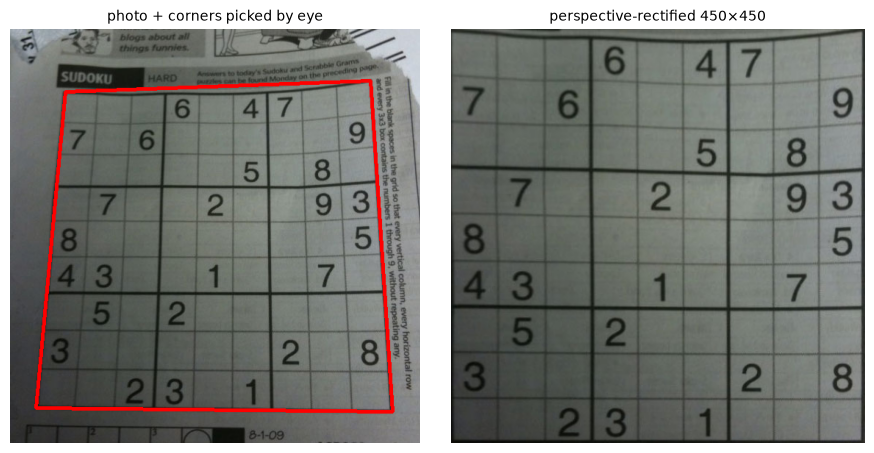

In [11]:
corners_by_eye = np.float32([[75, 85], [490, 70], [520, 520], [35, 515]])   # (x, y): top-left, top-right, bottom-right, bottom-left
SIDE = 450                                                                   # output square, 50 px per sudoku cell
square = np.float32([[0, 0], [SIDE - 1, 0], [SIDE - 1, SIDE - 1], [0, SIDE - 1]])
H_eye = cv2.getPerspectiveTransform(corners_by_eye, square)
rectified_eye = cv2.warpPerspective(sudoku, H_eye, (SIDE, SIDE))
print("homography H (3×3):\n", H_eye)

mapped = cv2.perspectiveTransform(corners_by_eye.reshape(-1, 1, 2), H_eye).reshape(-1, 2)
print("the 4 corners land on:\n", mapped.round(2))

annotated = sudoku.copy()
cv2.polylines(annotated, [corners_by_eye.astype(np.int32)], isClosed=True, color=(0, 0, 255), thickness=3)
show([annotated, rectified_eye], ["photo + corners picked by eye", "perspective-rectified 450×450"], size=4.5)

### ✍️ Your Turn

Make a thumbnail of `smarties` that is **200 pixels wide** and keeps the aspect ratio (round the height to the nearest integer). Store it in `thumb`. Remember: `cv2.resize` takes `dsize=(width, height)`.

In [12]:
thumb = None  # TODO: your code here
check("thumb_shape", None if thumb is None else thumb.shape, (172, 200, 3),
      hint="new_h = round(h * 200 / w); cv2.resize(smarties, (200, new_h), interpolation=cv2.INTER_AREA)")

⏳ thumb_shape: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
h, w = smarties.shape[:2]
new_h = int(round(h * 200 / w))                     # 356 * 200 / 413 = 172.4 → 172
thumb = cv2.resize(smarties, (200, new_h), interpolation=cv2.INTER_AREA)
check("thumb_shape", thumb.shape, (172, 200, 3))
```

`INTER_AREA` because we are shrinking. Passing `(new_h, 200)` would silently produce a squashed 172-wide, 200-tall image.
</details>

> 💡 **Interview angle:** "Affine vs perspective transform?" — affine (2×3, 6 DoF) keeps parallel lines parallel and needs 3 point pairs; a homography (3×3, 8 DoF, defined up to scale) models a plane seen from a different camera angle and needs 4. Also: shrink with `INTER_AREA`, resize masks with `INTER_NEAREST`.

## 5. Convolution and Filtering 🟡

A **filter** slides a small grid of weights — the **kernel** — over the image. At every position it multiplies the kernel with the pixels underneath and sums them; the sum becomes the output pixel.

```
  image patch        kernel (3×3 box)         output pixel
  [10 10 10]         [1/9 1/9 1/9]
  [10 200 10]   ⊙    [1/9 1/9 1/9]    →   (8·10 + 200) / 9 = 31.1
  [10 10 10]         [1/9 1/9 1/9]
```

- Strictly, sliding *without* flipping the kernel is **cross-correlation**; true **convolution** flips the kernel first. `cv2.filter2D` does correlation — identical for symmetric kernels like blurs, different for asymmetric ones like Sobel. (CNN "convolution" layers also compute correlation.)
- At the **border** the kernel hangs off the image, so OpenCV invents pixels: the default `BORDER_REFLECT_101` mirrors the image without repeating the edge pixel (`d c b | a b c d | c b a`).

| Filter | Output pixel = | Best for | Downside |
|---|---|---|---|
| **Box** `cv2.blur` | plain average of the window | speed | blurs edges; blocky artifacts |
| **Gaussian** `cv2.GaussianBlur` | weighted average, near pixels count more | general noise before edges/thresholds | blurs edges |
| **Median** `cv2.medianBlur` | the median of the window | **salt-and-pepper** (isolated bright/dark dots) | slow for big windows; rounds corners |
| **Bilateral** `cv2.bilateralFilter` | average of neighbours that are close in *position AND brightness* | smoothing **while keeping edges** | much slower |

In [13]:
tiny = np.full((5, 5), 10.0)
tiny[2, 2] = 200.0
print("box 3×3 on a single bright pixel:\n", cv2.filter2D(tiny, -1, np.ones((3, 3)) / 9))

box 3×3 on a single bright pixel:
 [[10.    10.    10.    10.    10.   ]
 [10.    31.111 31.111 31.111 10.   ]
 [10.    31.111 31.111 31.111 10.   ]
 [10.    31.111 31.111 31.111 10.   ]
 [10.    10.    10.    10.    10.   ]]


Let's compare the four filters properly. We take a real photo (scikit-learn's flower picture), add two kinds of noise ourselves (so we know the clean truth), and measure:

- **PSNR** against the clean image (higher = better denoising),
- **edge strength kept**: apply the filter to the *clean* image and compare the average gradient on its strongest edges (1.0 = edges as sharp as before).

All kernels are 3×3 except the bilateral filter's 9-pixel neighbourhood.

In [14]:
flower = cv2.cvtColor(load_sample_image("flower.jpg"), cv2.COLOR_RGB2BGR)
clean = cv2.cvtColor(flower, cv2.COLOR_BGR2GRAY)
gauss_noisy = np.clip(clean.astype(np.float64) + rng.normal(0, 20, clean.shape), 0, 255).astype(np.uint8)
salt_pepper = clean.copy()
u = rng.random(clean.shape)
salt_pepper[u < 0.025] = 0
salt_pepper[u > 0.975] = 255


def grad_mag(img):
    return cv2.magnitude(cv2.Sobel(img, cv2.CV_64F, 1, 0), cv2.Sobel(img, cv2.CV_64F, 0, 1))


strong_edges = grad_mag(clean) >= np.percentile(grad_mag(clean), 90)
filters = {
    "box 3×3": lambda im: cv2.blur(im, (3, 3)),
    "Gaussian 3×3": lambda im: cv2.GaussianBlur(im, (3, 3), 0),
    "median 3": lambda im: cv2.medianBlur(im, 3),
    "bilateral d=9": lambda im: cv2.bilateralFilter(im, 9, 50, 50),
}
rows = [{"filter": "(no filter)", "PSNR Gaussian noise": cv2.PSNR(clean, gauss_noisy),
         "PSNR salt & pepper": cv2.PSNR(clean, salt_pepper), "edge strength kept": 1.0, "ms": 0.0}]
for name, f in filters.items():
    start = time.perf_counter()
    denoised_gauss = f(gauss_noisy)
    elapsed = (time.perf_counter() - start) * 1000
    rows.append({"filter": name, "PSNR Gaussian noise": cv2.PSNR(clean, denoised_gauss),
                 "PSNR salt & pepper": cv2.PSNR(clean, f(salt_pepper)),
                 "edge strength kept": grad_mag(f(clean))[strong_edges].mean() / grad_mag(clean)[strong_edges].mean(),
                 "ms": elapsed})
filter_table = pd.DataFrame(rows).set_index("filter")
print(filter_table.round(3))

only_filters = filter_table.drop(index="(no filter)")
print("\nbest on Gaussian noise   :", only_filters["PSNR Gaussian noise"].idxmax())
print("best on salt & pepper    :", only_filters["PSNR salt & pepper"].idxmax())
print("keeps edges sharpest     :", only_filters["edge strength kept"].idxmax())

               PSNR Gaussian noise  PSNR salt & pepper  edge strength kept  \
filter                                                                       
(no filter)                 22.417              17.550               1.000   
box 3×3                     29.645              25.765               0.726   
Gaussian 3×3                29.587              25.215               0.784   
median 3                    28.666              35.634               0.831   
bilateral d=9               31.557              17.995               0.616   

                  ms  
filter                
(no filter)    0.000  
box 3×3        0.610  
Gaussian 3×3   1.287  
median 3       0.460  
bilateral d=9  0.917  

best on Gaussian noise   : bilateral d=9
best on salt & pepper    : median 3
keeps edges sharpest     : median 3


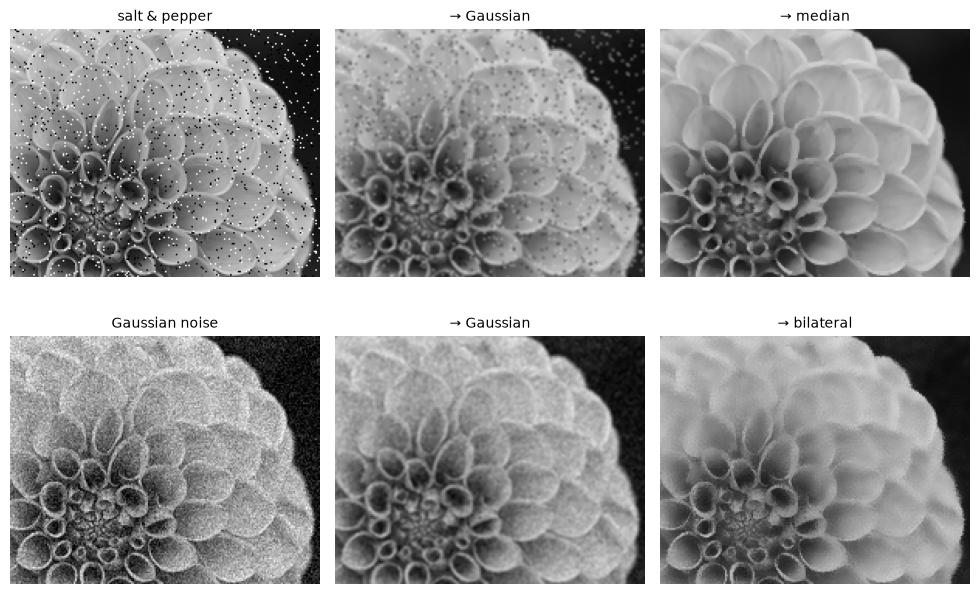

In [15]:
zoom = (slice(100, 260), slice(250, 450))              # zoom in so the differences are visible
show([salt_pepper[zoom], filters["Gaussian 3×3"](salt_pepper)[zoom], filters["median 3"](salt_pepper)[zoom],
      gauss_noisy[zoom], filters["Gaussian 3×3"](gauss_noisy)[zoom], filters["bilateral d=9"](gauss_noisy)[zoom]],
     ["salt & pepper", "→ Gaussian", "→ median", "Gaussian noise", "→ Gaussian", "→ bilateral"], cols=3, size=3.3)

The ranking depends on the image. Re-run the comparison with `clean = cv2.cvtColor(china, cv2.COLOR_BGR2GRAY)` — a photo full of fine texture — and some blurs *lower* the PSNR, because they erase real detail faster than they remove noise. Measure on images like yours instead of trusting a rule of thumb.


### ✍️ Your Turn

Build a **5×5 box kernel** yourself (all weights equal, summing to 1) and apply it to `clean` with `cv2.filter2D`. Store the result in `my_box`; it should match `cv2.blur(clean, (5, 5))`.

In [16]:
my_box = None  # TODO: your code here
check("my_box", my_box, cv2.blur(clean, (5, 5)), hint="kernel = np.ones((5, 5)) / 25, then cv2.filter2D(clean, -1, kernel). -1 means 'same depth as input'.")

⏳ my_box: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
kernel = np.ones((5, 5), np.float64) / 25
my_box = cv2.filter2D(clean, -1, kernel)
check("my_box", my_box, cv2.blur(clean, (5, 5)))
```

If the kernel did not sum to 1, the image would get brighter (sum > 1) or darker (sum < 1).
</details>

> 💡 **Interview angle:** "Why is a Gaussian blur fast even with a big kernel?" — it is **separable**: a k×k Gaussian equals a 1-D k-tap blur along rows then along columns, so the cost per pixel drops from k² to 2k multiplications (`cv2.sepFilter2D`). Box filters go further with integral images (constant cost regardless of size).

## 6. Image Gradients and Edges 🟡

An **edge** is where brightness changes quickly. The **gradient** measures that change: $G_x$ = change when you step **right** (along x), $G_y$ = change when you step **down** (along y). The **Sobel** operator estimates them with small kernels (a derivative in one direction combined with a little smoothing in the other):

```
       Gx kernel            Gy kernel
    [-1  0  +1]          [-1  -2  -1]
    [-2  0  +2]          [ 0   0   0]
    [-1  0  +1]          [+1  +2  +1]
```

🔑 **The rule people get backwards:** $G_x$ (the x-derivative, `dx=1`) responds to **vertical** edges — a vertical line is exactly where brightness changes as you move left→right. $G_y$ responds to **horizontal** edges.

Gradients are **negative** on bright→dark transitions, so compute them in a signed type (`CV_16S` or `CV_64F`), then take the absolute value with **`cv2.convertScaleAbs`**, which computes |value| and saturates to 0…255. Casting signed values straight to `uint8` wraps around instead (e.g. −4 becomes 252).

We verify the orientation rule on a *controlled synthetic* white square first:

In [17]:
square_img = np.zeros((60, 60), np.uint8)
square_img[15:45, 15:45] = 255
gx = cv2.Sobel(square_img, cv2.CV_16S, 1, 0, ksize=3)       # dx=1, dy=0
gy = cv2.Sobel(square_img, cv2.CV_16S, 0, 1, ksize=3)       # dx=0, dy=1
print("Gx is non-zero only in columns:", np.unique(np.nonzero(gx)[1]), "→ the LEFT and RIGHT (vertical) sides")
print("Gy is non-zero only in rows   :", np.unique(np.nonzero(gy)[0]), "→ the TOP and BOTTOM (horizontal) sides")
print("Gx min/max:", gx.min(), gx.max(), "→ negative where bright turns to dark")

wrapped = gx.astype(np.uint8)                              # ❌ −1020 wraps to a meaningless value
safe = cv2.convertScaleAbs(gx)                             # ✅ |−1020| = 1020 → saturates at 255
print("values after .astype(np.uint8):", np.unique(wrapped))
print("values after convertScaleAbs  :", np.unique(safe))

Gx is non-zero only in columns: [14 15 44 45] → the LEFT and RIGHT (vertical) sides
Gy is non-zero only in rows   : [14 15 44 45] → the TOP and BOTTOM (horizontal) sides
Gx min/max: -1020 1020 → negative where bright turns to dark
values after .astype(np.uint8): [  0   1   3   4 252 253 255]
values after convertScaleAbs  : [  0 255]


Now the real sudoku (the rectified version from section 4), where grid lines are clearly vertical or horizontal:

|Gx| column profile: peak/median = 19.8  vs row profile: 1.8  → Gx lines up with vertical lines


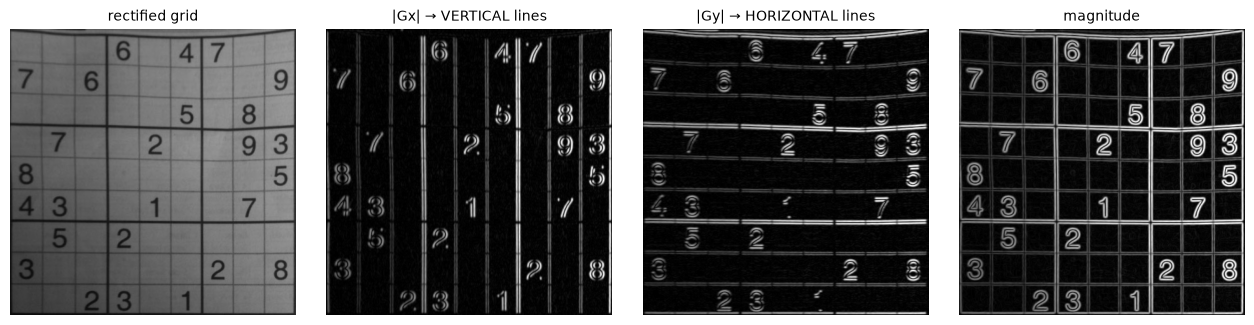

In [18]:
grid_eye_gray = cv2.cvtColor(rectified_eye, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(grid_eye_gray, (3, 3), 0)
gx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
magnitude = cv2.magnitude(gx, gy)                          # sqrt(gx² + gy²)
orientation = np.degrees(np.arctan2(gy, gx))               # gradient direction, perpendicular to the edge

# On a vertical grid line the columns are dark, so |Gx| summed down each column spikes at those columns
col_profile = np.abs(gx).sum(axis=0)
row_profile = np.abs(gx).sum(axis=1)
print(f"|Gx| column profile: peak/median = {col_profile.max() / np.median(col_profile):.1f}  "
      f"vs row profile: {row_profile.max() / np.median(row_profile):.1f}  → Gx lines up with vertical lines")
show([grid_eye_gray, cv2.convertScaleAbs(gx), cv2.convertScaleAbs(gy), cv2.convertScaleAbs(magnitude)],
     ["rectified grid", "|Gx| → VERTICAL lines", "|Gy| → HORIZONTAL lines", "magnitude"], cols=4, size=3.2)

**Canny** is the classic edge detector. Its steps:

1. **Smooth** (Gaussian) to suppress noise.
2. **Gradient** magnitude and direction (Sobel).
3. **Non-maximum suppression** — keep a pixel only if it is the strongest along the gradient direction, giving 1-pixel-thin edges.
4. **Double threshold + hysteresis** — pixels above `high` are sure edges; below `low` are dropped; in between are kept **only if connected to a sure edge**. This keeps long faint edges while ignoring isolated noise. Canny suggested `high` ≈ 2–3 × `low`.

A popular automatic rule sets the thresholds around the image's median brightness.

low=30, high=90      edge pixels: 8.64%
low=100, high=200    edge pixels: 3.60%
low=200, high=400    edge pixels: 0.07%
auto (median ± 33%)  edge pixels: 5.74%


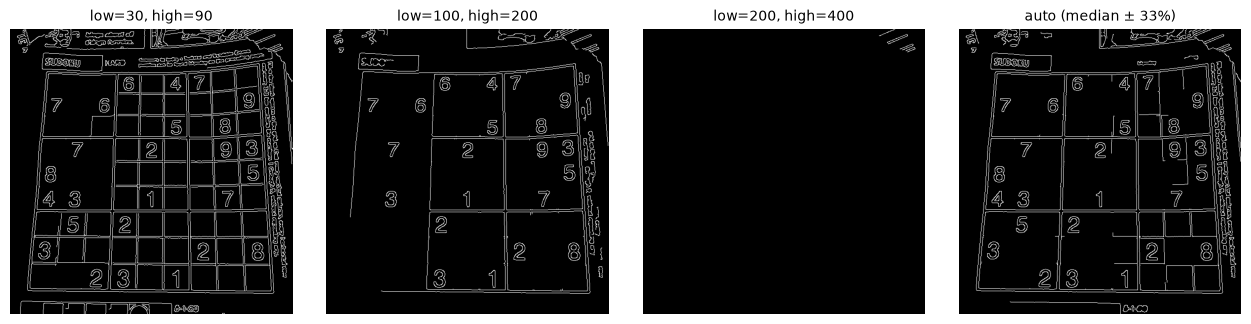

In [19]:
def auto_canny(img, sigma=0.33):
    median = float(np.median(img))
    return cv2.Canny(img, int(max(0, (1 - sigma) * median)), int(min(255, (1 + sigma) * median)))


blur5 = cv2.GaussianBlur(sudoku_gray, (5, 5), 0)
edge_maps = {"low=30, high=90": cv2.Canny(blur5, 30, 90),
             "low=100, high=200": cv2.Canny(blur5, 100, 200),
             "low=200, high=400": cv2.Canny(blur5, 200, 400),
             "auto (median ± 33%)": auto_canny(blur5)}
for name, e in edge_maps.items():
    print(f"{name:20s} edge pixels: {(e > 0).mean():.2%}")
show(list(edge_maps.values()), list(edge_maps.keys()), cols=4, size=3.2)

Lower thresholds keep paper texture and shadow noise; higher thresholds lose faint grid lines. There is no universally right value — you pick it on development images and check it on held-out ones (exactly what the mini project does).

### ✍️ Your Turn

`stripes_h` below has **horizontal** stripes. Compute the total absolute Sobel response for `dx=1` and for `dy=1` (use `cv2.CV_64F`), and set `stronger` to the string `"dx"` or `"dy"` — whichever is larger. Predict first!

In [20]:
stripes_h = np.zeros((60, 60), np.uint8)
stripes_h[::6, :] = 255
stronger = None  # TODO: your code here
check("stronger", stronger, "dy", hint="np.abs(cv2.Sobel(stripes_h, cv2.CV_64F, 1, 0)).sum() vs the dy=1 version.")

⏳ stronger: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
stripes_h = np.zeros((60, 60), np.uint8)
stripes_h[::6, :] = 255
total_dx = np.abs(cv2.Sobel(stripes_h, cv2.CV_64F, 1, 0)).sum()
total_dy = np.abs(cv2.Sobel(stripes_h, cv2.CV_64F, 0, 1)).sum()
stronger = "dx" if total_dx > total_dy else "dy"
check("stronger", stronger, "dy")
```

Horizontal stripes change brightness only as you move **down**, so the y-derivative fires and the x-derivative is exactly zero.
</details>

> 💡 **Interview angle:** "Walk me through Canny." — Gaussian smoothing → Sobel gradients → non-maximum suppression (thin edges) → double threshold → hysteresis (weak edges survive only if connected to strong ones). Bonus: `dx=1` detects *vertical* edges, and compute gradients in a signed dtype.

## 7. Thresholding: Global, Otsu, Adaptive 🟢

**Thresholding** turns a grayscale image into a **binary mask** (0 or 255): "is this pixel ink or paper?"

- **Global threshold** — one number for the whole image: `pixel > T`.
- **Otsu's method** — picks `T` automatically by trying all 256 values and choosing the one that best separates the histogram into two groups (maximum *between-class variance*). Works when the histogram has two clear humps.
- **Adaptive threshold** — a different `T` for every pixel, computed from its neighbourhood (mean or Gaussian-weighted mean minus a constant `C`). Works under **uneven lighting**.

The sudoku photo has a shadow: its bottom-left is much darker than its top-right. Watch what a single global threshold does to each quadrant.

In [21]:
otsu_T, otsu_mask = cv2.threshold(sudoku_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)   # INV: dark ink → 255
_, fixed_mask = cv2.threshold(sudoku_gray, 127, 255, cv2.THRESH_BINARY_INV)
adaptive_mask = cv2.adaptiveThreshold(sudoku_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV,
                                      blockSize=11, C=2)
print("Otsu picked T =", otsu_T)

hh, hw = sudoku_gray.shape[0] // 2, sudoku_gray.shape[1] // 2
quadrants = {"top-left": (slice(0, hh), slice(0, hw)), "top-right": (slice(0, hh), slice(hw, None)),
             "bottom-left": (slice(hh, None), slice(0, hw)), "bottom-right": (slice(hh, None), slice(hw, None))}
table = pd.DataFrame({
    "mean brightness": {q: sudoku_gray[s].mean() for q, s in quadrants.items()},
    "ink % fixed T=127": {q: (fixed_mask[s] > 0).mean() * 100 for q, s in quadrants.items()},
    "ink % Otsu": {q: (otsu_mask[s] > 0).mean() * 100 for q, s in quadrants.items()},
    "ink % adaptive": {q: (adaptive_mask[s] > 0).mean() * 100 for q, s in quadrants.items()},
})
print(table.round(1))
spread = (table.drop(columns="mean brightness").max() - table.drop(columns="mean brightness").min()).round(1)
print("\nspread of ink % across quadrants (a printed page should be similar everywhere):")
print(spread.to_string())
print("most lighting-robust method:", spread.idxmin())

Otsu picked T = 97.0
              mean brightness  ink % fixed T=127  ink % Otsu  ink % adaptive
top-left                 99.3               92.9        36.1            21.5
top-right               127.2               35.9        16.1            26.3
bottom-left              71.4              100.0        89.1            18.3
bottom-right            111.8               66.9        22.6            22.7

spread of ink % across quadrants (a printed page should be similar everywhere):
ink % fixed T=127    64.1
ink % Otsu           73.0
ink % adaptive        8.0
most lighting-robust method: ink % adaptive


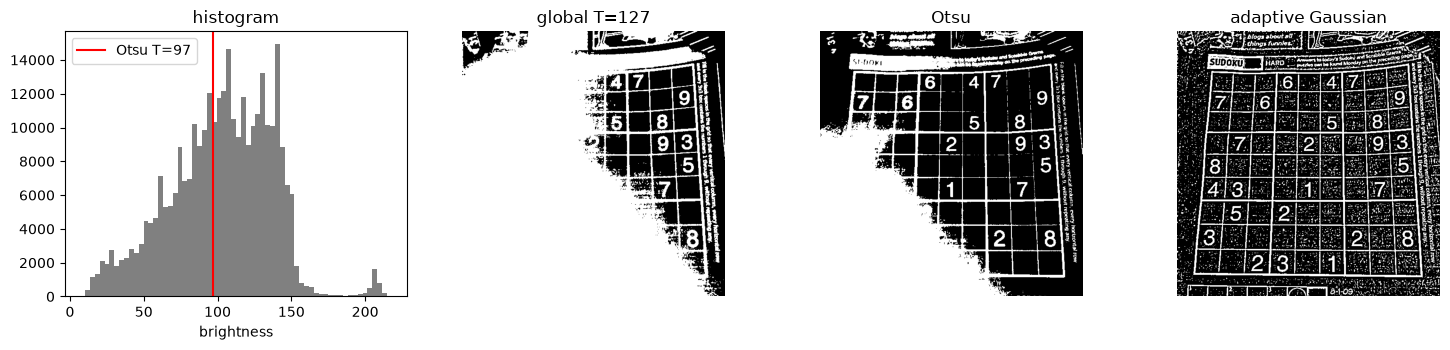

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
axes[0].hist(sudoku_gray.ravel(), bins=64, color="gray")
axes[0].axvline(otsu_T, color="red", label=f"Otsu T={otsu_T:.0f}")
axes[0].set(title="histogram", xlabel="brightness")
axes[0].legend()
for ax, img, title in zip(axes[1:], [fixed_mask, otsu_mask, adaptive_mask], ["global T=127", "Otsu", "adaptive Gaussian"]):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

> 💡 **Interview angle:** "Otsu picked a bad threshold — why?" — Otsu assumes a two-hump histogram and one lighting condition. With shadows or gradients, use adaptive thresholding (or normalise lighting first, e.g. CLAHE or dividing by a heavily blurred background).

## 8. Morphology 🟢

**Morphological operations** reshape white regions of a binary mask using a small shape called the **structuring element** (a rectangle, ellipse, or cross):

| Operation | Rule | Effect | Typical use |
|---|---|---|---|
| **Erode** | pixel stays white only if *all* neighbours are white | shrinks blobs, deletes specks | separate touching objects |
| **Dilate** | pixel becomes white if *any* neighbour is white | grows blobs, fills gaps | join broken strokes |
| **Open** = erode → dilate | removes things smaller than the element | **remove noise specks** | clean a mask |
| **Close** = dilate → erode | fills holes smaller than the element | **fill small holes** | solid objects |

Analogy: *opening* is sanding a wooden board (tiny splinters disappear, the board keeps its shape); *closing* is filling cracks with putty.

raw Otsu mask    white=19.20%  blobs= 14  holes= 15
eroded           white=15.92%  blobs= 14  holes=  9
dilated          white=22.43%  blobs= 12  holes=  3
opened           white=19.14%  blobs= 13  holes= 11
opened + closed  white=19.27%  blobs= 12  holes=  2


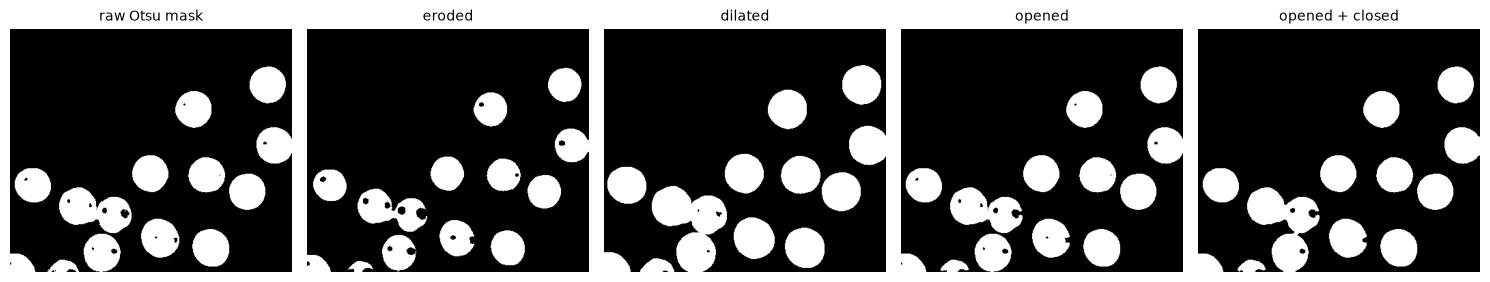

In [23]:
_, sat_mask = cv2.threshold(S, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)   # candies are saturated, background isn't
ellipse5 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))


def count_blobs_and_holes(mask):
    contours, hierarchy = cv2.findContours(mask, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    if hierarchy is None:
        return 0, 0
    parents = hierarchy[0][:, 3]                     # -1 = outer boundary, otherwise it's a hole inside a blob
    return int((parents == -1).sum()), int((parents != -1).sum())


steps = {"raw Otsu mask": sat_mask,
         "eroded": cv2.erode(sat_mask, ellipse5),
         "dilated": cv2.dilate(sat_mask, ellipse5),
         "opened": cv2.morphologyEx(sat_mask, cv2.MORPH_OPEN, ellipse5)}
steps["opened + closed"] = cv2.morphologyEx(steps["opened"], cv2.MORPH_CLOSE, ellipse5)
for name, m in steps.items():
    blobs, holes = count_blobs_and_holes(m)
    print(f"{name:16s} white={(m > 0).mean():6.2%}  blobs={blobs:3d}  holes={holes:3d}")
show(list(steps.values()), list(steps.keys()), cols=5, size=3)

Read the table carefully: opening removed specks and closing filled highlight holes — but closing **also merged nearby candies** (the blob count dropped). Every morphology step is a trade-off between cleaning and merging.

Morphology with **long, thin** structuring elements is a neat trick: opening with a 40×1 horizontal line keeps only horizontal structures at least 40 px long — the sudoku grid lines — and removes the digits.

digit-sized components: 27 | digits printed in this puzzle (counted by eye): 26


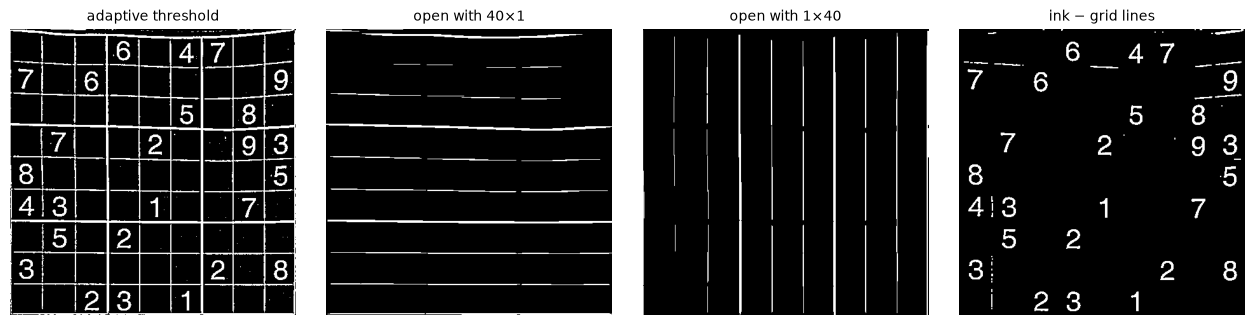

In [24]:
ink = cv2.adaptiveThreshold(grid_eye_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 5)
horizontal = cv2.morphologyEx(ink, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1)))
vertical = cv2.morphologyEx(ink, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (1, 40)))
grid_lines = cv2.dilate(cv2.bitwise_or(horizontal, vertical), np.ones((3, 3), np.uint8))
digits_only = cv2.morphologyEx(cv2.bitwise_and(ink, cv2.bitwise_not(grid_lines)), cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))

n, _, digit_stats, _ = cv2.connectedComponentsWithStats(digits_only)
big_enough = digit_stats[1:, cv2.CC_STAT_HEIGHT] >= 15          # digits are ~30 px tall in a 50 px cell
print("digit-sized components:", int(big_enough.sum()), "| digits printed in this puzzle (counted by eye): 26")
show([ink, horizontal, vertical, digits_only], ["adaptive threshold", "open with 40×1", "open with 1×40", "ink − grid lines"], cols=4, size=3.2)

The count is close to, but not exactly, the 26 digits printed in the grid — a simple height rule on a real photo is rarely perfect, which is why we never trust a pipeline without measuring it.

> 💡 **Interview angle:** "How would you remove small noise from a segmentation mask?" — morphological opening (erode then dilate) with an element slightly larger than the noise; closing to fill holes; or drop connected components below a minimum area. Mention that it runs in microseconds and is a standard post-processing step even for deep-learning masks.

## 9. Contours and Shape Features 🟡

A **contour** is the outline of a white blob: a list of `(x, y)` boundary points. `cv2.findContours(mask, mode, method)`:

- `mode=cv2.RETR_EXTERNAL` → only outer outlines (ignore holes); `RETR_CCOMP`/`RETR_TREE` → also holes, with a hierarchy.
- `method=cv2.CHAIN_APPROX_SIMPLE` → compress straight runs to their endpoints (a rectangle becomes 4 points).

From a contour you can measure **shape features**:

| Feature | API | Meaning |
|---|---|---|
| area, perimeter | `contourArea`, `arcLength(c, True)` | size |
| centroid | `moments(c)` → `(m10/m00, m01/m00)` | center of mass |
| bounding box | `boundingRect` / `minAreaRect` | axis-aligned / rotated box |
| enclosing circle | `minEnclosingCircle` | center and radius |
| **circularity** | $4\pi \cdot \text{area} / \text{perimeter}^2$ | 1.0 for a perfect circle, ≈0.785 for a square, lower for irregular shapes |
| polygon approx | `approxPolyDP(c, eps, True)` | simplify to corners (4 ⇒ quadrilateral) |

        cx      cy    area  perimeter  circularity  enclosing_r  bbox_w  bbox_h                       note
0   126.50  286.96  6588.0     532.70         0.29        66.21     106     124  several candies touching?
1   218.66  305.92  2345.5     193.58         0.79        29.15      55      57                           
2   293.91  320.15  2287.0     178.85         0.90        28.60      54      55                           
3   386.97  170.14  2183.0     176.37         0.88        27.89      52      54                           
4   377.11   81.34  2164.5     174.27         0.90        26.85      53      54                           
5   347.11  237.85  2161.0     174.02         0.90        27.04      53      53                           
6   205.00  211.22  2155.0     173.68         0.90        27.13      53      54                           
7   268.60  117.18  2151.0     173.68         0.90        26.93      53      54                           
8   287.63  213.43  2092.5     172.27

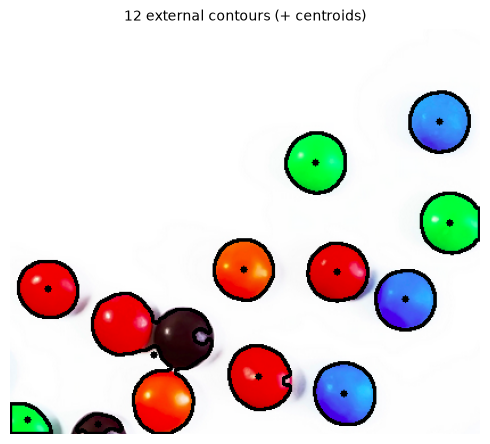

In [25]:
candy_mask = steps["opened + closed"]
contours, _ = cv2.findContours(candy_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
records = []
for c in contours:
    area, perim = cv2.contourArea(c), cv2.arcLength(c, True)
    m = cv2.moments(c)
    (cx_circle, cy_circle), radius = cv2.minEnclosingCircle(c)
    x, y, bw, bh = cv2.boundingRect(c)
    records.append({"cx": m["m10"] / m["m00"], "cy": m["m01"] / m["m00"], "area": area, "perimeter": perim,
                    "circularity": 4 * np.pi * area / perim ** 2, "enclosing_r": radius, "bbox_w": bw, "bbox_h": bh})
shape_df = pd.DataFrame(records).sort_values("area", ascending=False).reset_index(drop=True)
median_area = shape_df["area"].median()
shape_df["note"] = np.select([shape_df["area"] > 1.5 * median_area, shape_df["area"] < 0.5 * median_area],
                             ["several candies touching?", "cut off by border?"], default="")
print(shape_df.round(2).to_string())
print(f"\nlargest blob = {shape_df['area'].max() / median_area:.1f}× the median blob area")

drawn = smarties.copy()
cv2.drawContours(drawn, contours, -1, (0, 0, 0), 2)
for r in records:
    cv2.circle(drawn, (int(r["cx"]), int(r["cy"])), 3, (0, 0, 0), -1)        # OpenCV points are (x, y)
show(drawn, f"{len(contours)} external contours (+ centroids)", size=5)

The contour table *explains its own mistakes*: the largest blob is several times the median area with very low circularity — touching candies merged into one contour — and two small blobs are candies cut off by the image border. Keep that in mind for the mini project.

Contours also find the sudoku grid **automatically**: the grid is the largest outline, and `approxPolyDP` simplifies it to 4 corners.

automatic corners:
 [[ 73.  84.]
 [492.  69.]
 [520. 522.]
 [ 34. 516.]]
distance from the corners picked by eye (px): [2.2 2.2 2.  1.4]


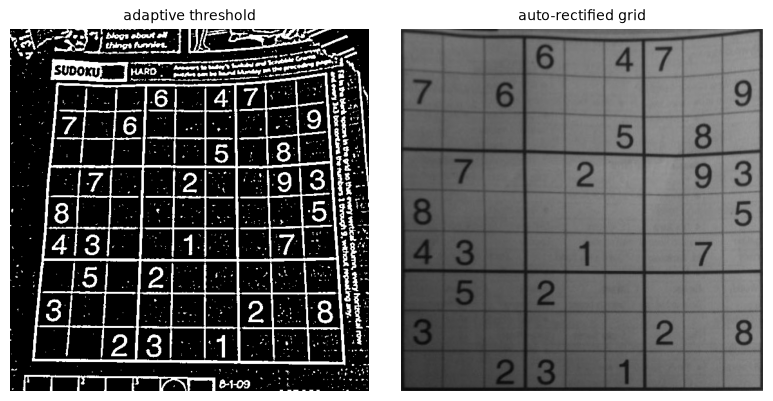

In [26]:
binary = cv2.adaptiveThreshold(cv2.GaussianBlur(sudoku_gray, (5, 5), 0), 255,
                               cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
outer, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
grid_contour = max(outer, key=cv2.contourArea)
approx = cv2.approxPolyDP(grid_contour, 0.02 * cv2.arcLength(grid_contour, True), True)
if len(approx) != 4:
    raise RuntimeError(f"expected 4 corners, got {len(approx)} — try a different epsilon")


def order_corners(points):
    """Return corners as top-left, top-right, bottom-right, bottom-left."""
    pts = points.reshape(4, 2).astype(np.float32)
    s, d = pts.sum(axis=1), pts[:, 1] - pts[:, 0]        # x+y: min=TL, max=BR | y−x: min=TR, max=BL
    return np.float32([pts[s.argmin()], pts[d.argmin()], pts[s.argmax()], pts[d.argmax()]])


corners_auto = order_corners(approx)
print("automatic corners:\n", corners_auto)
print("distance from the corners picked by eye (px):", np.linalg.norm(corners_auto - corners_by_eye, axis=1).round(1))
H_auto = cv2.getPerspectiveTransform(corners_auto, square)
grid_gray = cv2.warpPerspective(sudoku_gray, H_auto, (SIDE, SIDE))
show([binary, grid_gray], ["adaptive threshold", "auto-rectified grid"], size=4)

### ✍️ Your Turn

Find the contour of the white square in `square_img` (from section 6) and compute its **circularity** $4\pi A / P^2$. Store the number in `square_circularity`.

In [27]:
square_circularity = None  # TODO: your code here
check("square_circularity", square_circularity, np.pi / 4, atol=0.01,
      hint="contours, _ = cv2.findContours(square_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE); use contourArea and arcLength(c, True).")

⏳ square_circularity: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
sq_contours, _ = cv2.findContours(square_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
c = sq_contours[0]
square_circularity = 4 * np.pi * cv2.contourArea(c) / cv2.arcLength(c, True) ** 2
check("square_circularity", square_circularity, np.pi / 4, atol=0.01)
```

For a square of side s: $4\pi s^2 / (4s)^2 = \pi/4 \approx 0.785$. Contours run through pixel *centers*, so a 30-pixel-wide square has a contour side of 29 — the ratio is unchanged.
</details>

> 💡 **Interview angle:** "How would you build a document scanner?" — grayscale → blur → adaptive threshold or Canny → largest contour → `approxPolyDP` to 4 corners → order corners → `getPerspectiveTransform` → `warpPerspective`. Mention failure cases: page not fully visible, low contrast with the table, curled pages (not planar → no single homography).

## 10. Histograms and CLAHE 🟡

A **histogram** counts how many pixels have each brightness. A dim, low-contrast photo squeezes its histogram into a narrow band.

- **Histogram equalization** (`cv2.equalizeHist`) remaps brightness so the cumulative histogram becomes a straight line — it spreads values over the full 0–255 range. It is *global*: one mapping for the whole image, so it also boosts noise in flat areas.
- **CLAHE** (*Contrast-Limited Adaptive Histogram Equalization*) equalizes small tiles (e.g. 8×8 grid) separately, **clips** each tile's histogram at `clipLimit` so noise isn't over-amplified, and blends tiles smoothly. It's the standard choice for medical images, underwater photos, and night scenes.

We measure two things: global contrast (standard deviation of all pixels) and **noise amplification** in a flat patch of blank paper (standard deviation inside it — ideally it stays small).

              global std (contrast)  1st–99th percentile  \
image                                                      
original                      34.42                180.0   
equalizeHist                  73.82                249.0   
CLAHE clip=2                  42.64                200.0   

              flat-patch std (noise)  
image                                 
original                        3.78  
equalizeHist                    9.60  
CLAHE clip=2                    8.26  

noise amplification vs original: {'original': 1.0, 'equalizeHist': 2.54, 'CLAHE clip=2': 2.18}


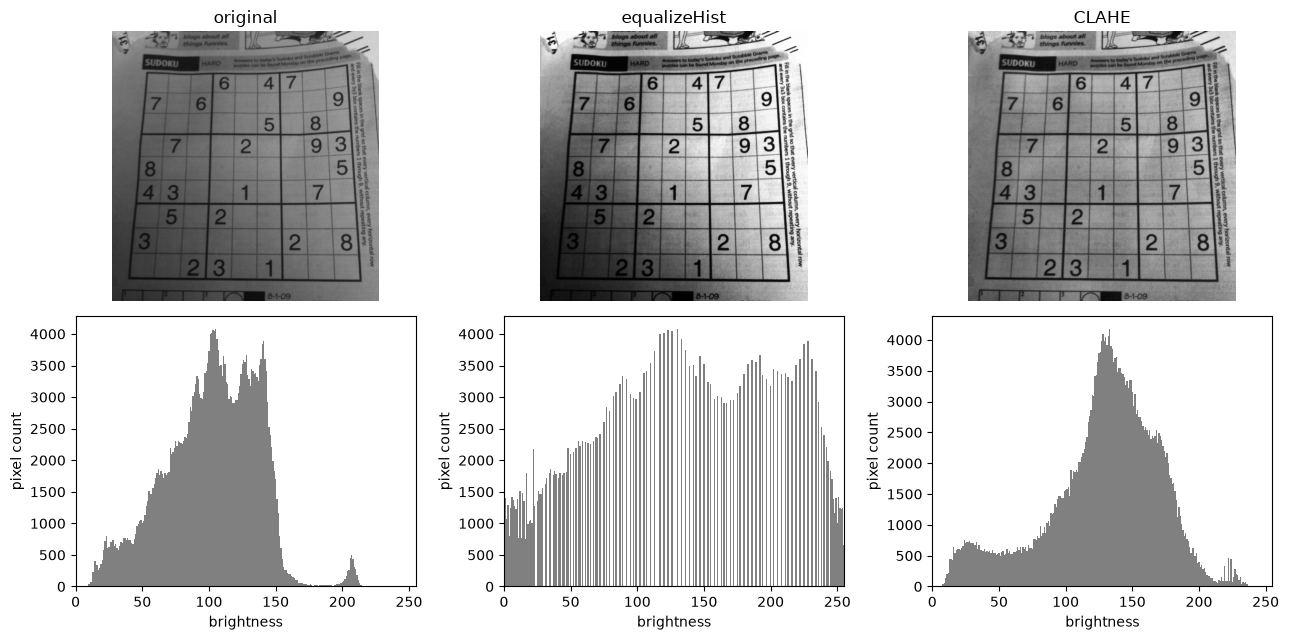

In [28]:
flat_patch = (slice(185, 210), slice(85, 110))              # a blank piece of paper in the photo
equalized = cv2.equalizeHist(sudoku_gray)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(sudoku_gray)
hist_rows = []
for name, img in [("original", sudoku_gray), ("equalizeHist", equalized), ("CLAHE clip=2", clahe)]:
    hist_rows.append({"image": name, "global std (contrast)": img.std(), "1st–99th percentile": np.ptp(np.percentile(img, [1, 99])),
                      "flat-patch std (noise)": img[flat_patch].std()})
hist_df = pd.DataFrame(hist_rows).set_index("image")
print(hist_df.round(2))
amplification = hist_df["flat-patch std (noise)"] / hist_df.loc["original", "flat-patch std (noise)"]
print("\nnoise amplification vs original:", amplification.round(2).to_dict())

fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for i, (name, img) in enumerate([("original", sudoku_gray), ("equalizeHist", equalized), ("CLAHE", clahe)]):
    axes[0, i].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[0, i].set_title(name)
    axes[0, i].axis("off")
    hist = cv2.calcHist([img], [0], None, [256], [0, 256]).ravel()     # images list, channel, mask, bins, range
    axes[1, i].bar(np.arange(256), hist, width=1, color="gray")
    axes[1, i].set(xlim=(0, 255), xlabel="brightness", ylabel="pixel count")
plt.tight_layout()
plt.show()

> 💡 **Interview angle:** "Histogram equalization vs CLAHE?" — global equalization uses one mapping and amplifies noise in flat regions; CLAHE works per tile with a clip limit, so it enhances local contrast without blowing up noise. For color images, apply it to the L channel of LAB (or V of HSV), not to B, G, R separately — that shifts colors.

## 11. Template Matching with Non-Maximum Suppression 🟡

**Template matching** slides a small image (the *template*) over a bigger one and scores every position. With `cv2.TM_CCOEFF_NORMED` the score is a normalized correlation in [−1, 1] (1 = perfect match; brightness and contrast changes don't matter). The result map has shape `(H − h + 1, W − w + 1)`.

Two things go wrong constantly:

1. **A good match lights up a whole neighbourhood** of positions (shifted by 1–2 px the score is still high) — so "count positions above a threshold" hugely over-counts. The fix is **non-maximum suppression (NMS)**: keep the best box, delete every box that overlaps it too much, repeat.
2. **A flat, featureless template** (e.g. a patch of blank paper) matches everywhere. Templates need texture.

Overlap is measured by **IoU** (intersection over union): area where two boxes overlap ÷ area covered by either.

```
  ┌──────┐
  │  A ┌─┼────┐        IoU = |A ∩ B| / |A ∪ B|
  │    │▓│    │        0 = disjoint, 1 = identical
  └────┼─┘  B │
       └──────┘
```

### ✍️ Your Turn

Write `iou(a, b)` for boxes given as `(x, y, w, h)`. Two 10×10 boxes offset by (5, 5) overlap in a 5×5 square, so IoU = 25 / (100 + 100 − 25) = 1/7.

In [29]:
def iou(a, b):
    return None  # TODO: compute intersection width/height (clip at 0), then intersection / union


check("iou", iou((0, 0, 10, 10), (5, 5, 10, 10)), 25 / 175, hint="inter_w = max(0, min(ax+aw, bx+bw) − max(ax, bx)); same for h.")

⏳ iou: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def iou(a, b):
    ax, ay, aw, ah = a
    bx, by, bw, bh = b
    inter_w = max(0, min(ax + aw, bx + bw) - max(ax, bx))
    inter_h = max(0, min(ay + ah, by + bh) - max(ay, by))
    inter = inter_w * inter_h
    return inter / (aw * ah + bw * bh - inter)

check("iou", iou((0, 0, 10, 10), (5, 5, 10, 10)), 25 / 175)
check("iou disjoint", iou((0, 0, 10, 10), (20, 20, 5, 5)), 0.0)
```
</details>

Now the real task: **find every 7** in the auto-rectified sudoku grid. We cut the template from the 7 in row 1, column 0 — so that one match scores 1.0 *by construction*; the other 7s are the real test. The puzzle's printed 7s (read by eye) are at (row, col) = (0, 6), (1, 0), (3, 1), (5, 7).

In [30]:
CELL = SIDE // 9
cell = grid_gray[CELL:2 * CELL, 0:CELL]                                  # row 1, col 0
_, cell_ink = cv2.threshold(cell, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
cell_ink[:5, :] = 0                                                      # ignore grid lines at the cell border
cell_ink[-5:, :] = 0
cell_ink[:, :5] = 0
cell_ink[:, -5:] = 0
_, _, cell_stats, _ = cv2.connectedComponentsWithStats(cell_ink)
digit = 1 + np.argmax(cell_stats[1:, cv2.CC_STAT_AREA])
x, y, tw, th = cell_stats[digit, :4]
template = cell[max(y - 3, 0): y + th + 3, max(x - 3, 0): x + tw + 3]
th, tw = template.shape

scores = cv2.matchTemplate(grid_gray, template, cv2.TM_CCOEFF_NORMED)
print("grid", grid_gray.shape, "| template", template.shape, "| score map", scores.shape)

THRESHOLD = 0.6
ys, xs = np.nonzero(scores >= THRESHOLD)
boxes = np.stack([xs, ys, np.full_like(xs, tw), np.full_like(xs, th)], axis=1).astype(np.float64)
box_scores = scores[ys, xs]
print(f"positions with score ≥ {THRESHOLD}: {len(boxes)}  ← counting these would claim {len(boxes)} sevens")

grid (450, 450) | template (37, 30) | score map (414, 421)
positions with score ≥ 0.6: 119  ← counting these would claim 119 sevens


Greedy NMS, vectorized — the same algorithm used after every object detector (YOLO, Faster R-CNN):

our NMS keeps 4 | cv2.dnn.NMSBoxes keeps 4 | same boxes: True
detections (row, col) → score: {(1, 0): 1.0, (3, 1): 0.974, (0, 6): 0.948, (5, 7): 0.947}
precision = 1.00 | recall = 1.00
weakest true 7 scores 0.947 | strongest score in any other cell 0.558 → margin 0.389
threshold 0.6 sits inside the gap, so the result is not sensitive to its exact value


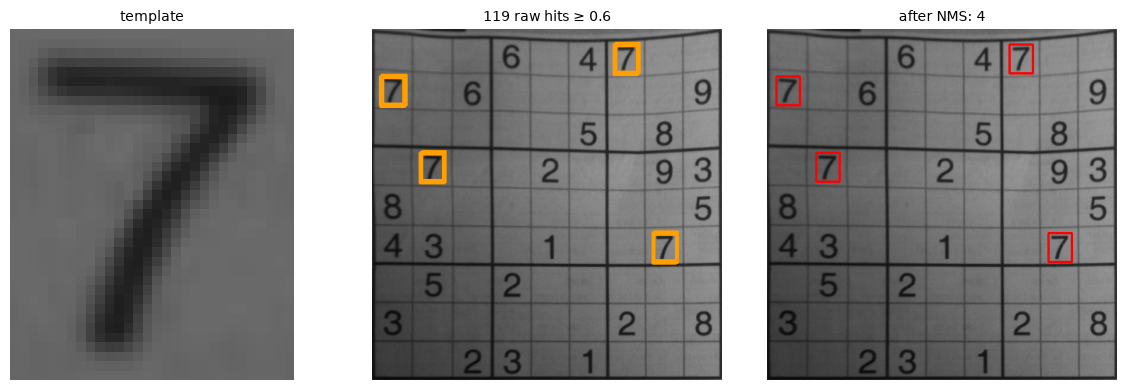

In [31]:
def iou_one_to_many(box, others):
    x1 = np.maximum(box[0], others[:, 0])
    y1 = np.maximum(box[1], others[:, 1])
    x2 = np.minimum(box[0] + box[2], others[:, 0] + others[:, 2])
    y2 = np.minimum(box[1] + box[3], others[:, 1] + others[:, 3])
    inter = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    return inter / (box[2] * box[3] + others[:, 2] * others[:, 3] - inter)


def nms(boxes, scores, iou_threshold=0.3):
    order = np.argsort(scores)[::-1]                      # best score first
    keep = []
    while order.size:
        best, rest = order[0], order[1:]
        keep.append(int(best))
        order = rest[iou_one_to_many(boxes[best], boxes[rest]) <= iou_threshold]   # drop heavy overlaps
    return keep


kept = nms(boxes, box_scores, iou_threshold=0.3)
kept_cv = cv2.dnn.NMSBoxes(boxes.tolist(), box_scores.tolist(), THRESHOLD, 0.3)
print("our NMS keeps", len(kept), "| cv2.dnn.NMSBoxes keeps", len(kept_cv), "| same boxes:", set(kept) == set(np.ravel(kept_cv).tolist()))

SEVENS = {(0, 6), (1, 0), (3, 1), (5, 7)}
found = {(int((ys[i] + th / 2) // CELL), int((xs[i] + tw / 2) // CELL)): round(float(box_scores[i]), 3) for i in kept}
tp = len(SEVENS & found.keys())
print("detections (row, col) → score:", found)
print(f"precision = {tp / max(len(found), 1):.2f} | recall = {tp / len(SEVENS):.2f}")

# How safe is the threshold? For every cell, take the best score of any template position centered inside it.
pos_y, pos_x = np.indices(scores.shape)
cell_row = np.clip((pos_y + th / 2) // CELL, 0, 8).astype(int)
cell_col = np.clip((pos_x + tw / 2) // CELL, 0, 8).astype(int)
best_per_cell = np.full((9, 9), -1.0)
np.maximum.at(best_per_cell, (cell_row.ravel(), cell_col.ravel()), scores.ravel())
is_seven = np.zeros((9, 9), bool)
for r, c in SEVENS:
    is_seven[r, c] = True
weakest_seven, strongest_other = best_per_cell[is_seven].min(), best_per_cell[~is_seven].max()
print(f"weakest true 7 scores {weakest_seven:.3f} | strongest score in any other cell {strongest_other:.3f} "
      f"→ margin {weakest_seven - strongest_other:.3f}")
if weakest_seven > THRESHOLD > strongest_other:
    print(f"threshold {THRESHOLD} sits inside the gap, so the result is not sensitive to its exact value")
else:
    print(f"threshold {THRESHOLD} is NOT inside the gap — results depend on it")

vis = cv2.cvtColor(grid_gray, cv2.COLOR_GRAY2BGR)
for i in kept:
    cv2.rectangle(vis, (int(xs[i]), int(ys[i])), (int(xs[i] + tw), int(ys[i] + th)), (0, 0, 255), 2)
raw_vis = cv2.cvtColor(grid_gray, cv2.COLOR_GRAY2BGR)
for bx, by, _, _ in boxes:
    cv2.rectangle(raw_vis, (int(bx), int(by)), (int(bx + tw), int(by + th)), (0, 160, 255), 1)
show([template, raw_vis, vis], ["template", f"{len(boxes)} raw hits ≥ {THRESHOLD}", f"after NMS: {len(kept)}"], size=4)

Template matching only works when the target appears at **the same scale, rotation, and style** as the template — here the grid was rectified first, which is why it works so well. For objects that rotate, scale, or change viewpoint, use feature matching (next section) or a learned detector.

> 💡 **Interview angle:** "Implement NMS." — sort by score; take the best; remove boxes with IoU above a threshold; repeat. O(n²) worst case. Know the knobs: IoU threshold (lower = more aggressive), class-aware vs class-agnostic NMS, and Soft-NMS (decay scores instead of deleting) for crowded scenes.

## 12. Feature Matching: ORB, Ratio Test, RANSAC Homography 🔴

Goal: find the cereal box (`box.png`) inside a cluttered photo (`box_in_scene.png`) where it is smaller, rotated, and partly hidden. The classic pipeline:

1. **Detect keypoints** — distinctive, repeatable spots (corners, blobs).
2. **Describe** each keypoint with a vector summarizing its neighbourhood. **ORB** (*Oriented FAST and Rotated BRIEF*) gives a 256-bit **binary** descriptor per keypoint: fast, free, rotation-invariant. SIFT gives 128 floats: slower, often more robust.
3. **Match** descriptors: brute force with **Hamming distance** (number of differing bits) for binary descriptors.
4. **Lowe's ratio test** — for each keypoint take its 2 nearest matches; keep it only if the best is clearly better than the runner-up (`d1 < 0.75·d2`). Repetitive textures produce ambiguous matches; this removes them.
5. **RANSAC homography** — *RANdom SAmple Consensus*: repeatedly pick 4 random matches, fit a homography, count how many other matches agree within a few pixels (**inliers**), keep the best. Wrong matches (outliers) can't agree with each other, so they are ignored.

keypoints: box 1589, scene 1999 | descriptor array (1589, 32) uint8 (32 bytes = 256 bits per keypoint)
nearest-neighbour matches: 1589 → after ratio test: 53
RANSAC inliers: 48 / 53 | inlier reprojection error: median 0.74 px, max 2.79 px


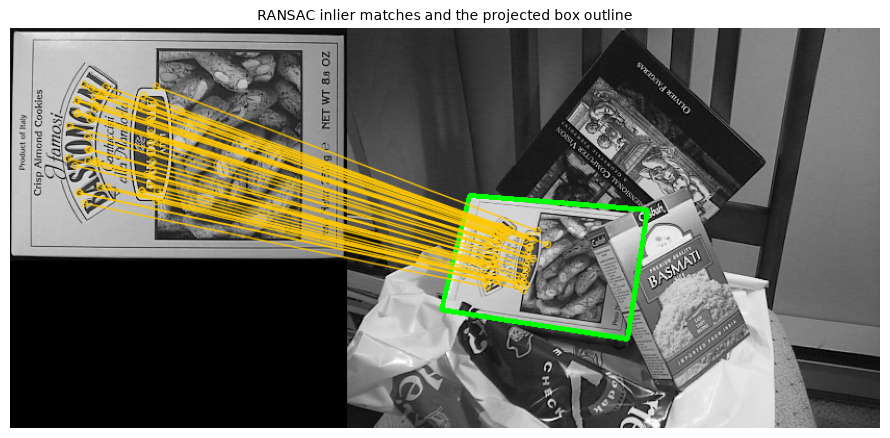

In [32]:
box_gray = cv2.imread(str(fetch("box.png")), cv2.IMREAD_GRAYSCALE)
scene_gray = cv2.imread(str(fetch("box_in_scene.png")), cv2.IMREAD_GRAYSCALE)
orb = cv2.ORB_create(nfeatures=2000)
kp_box, des_box = orb.detectAndCompute(box_gray, None)
kp_scene, des_scene = orb.detectAndCompute(scene_gray, None)
print(f"keypoints: box {len(kp_box)}, scene {len(kp_scene)} | descriptor array {des_box.shape} {des_box.dtype} "
      f"(32 bytes = 256 bits per keypoint)")

matcher = cv2.BFMatcher(cv2.NORM_HAMMING)
knn_pairs = matcher.knnMatch(des_box, des_scene, k=2)
good = [p[0] for p in knn_pairs if len(p) == 2 and p[0].distance < 0.75 * p[1].distance]
print(f"nearest-neighbour matches: {len(knn_pairs)} → after ratio test: {len(good)}")

src_pts = np.float32([kp_box[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
dst_pts = np.float32([kp_scene[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
H_box, inlier_mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, ransacReprojThreshold=5.0)
inliers = inlier_mask.ravel().astype(bool)
reproj = np.linalg.norm(cv2.perspectiveTransform(src_pts, H_box) - dst_pts, axis=2).ravel()
print(f"RANSAC inliers: {inliers.sum()} / {len(good)} | inlier reprojection error: "
      f"median {np.median(reproj[inliers]):.2f} px, max {reproj[inliers].max():.2f} px")

bh, bw = box_gray.shape
box_corners = np.float32([[0, 0], [bw - 1, 0], [bw - 1, bh - 1], [0, bh - 1]]).reshape(-1, 1, 2)
scene_corners = cv2.perspectiveTransform(box_corners, H_box)
scene_vis = cv2.cvtColor(scene_gray, cv2.COLOR_GRAY2BGR)
cv2.polylines(scene_vis, [np.int32(scene_corners)], True, (0, 255, 0), 3)
inlier_matches = [m for m, keep in zip(good, inliers) if keep]
match_vis = cv2.drawMatches(box_gray, kp_box, scene_vis, kp_scene, inlier_matches, None,
                            matchColor=(0, 200, 255), flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
show(match_vis, "RANSAC inlier matches and the projected box outline", size=9)

On the real photo we have no exact ground-truth outline, so the inlier count and reprojection error only tell us the matches are *consistent*. To measure *accuracy*, we build a **controlled test**: warp `box.png` with a homography we choose (plus a lighting change), run the same pipeline, and compare the recovered corners to the true ones.

In [33]:
def locate(template_gray, scene, ratio=0.75):
    """ORB + ratio test + RANSAC. Returns (H, n_good, n_inliers) — H is None when too few matches."""
    kp1, d1 = orb.detectAndCompute(template_gray, None)
    kp2, d2 = orb.detectAndCompute(scene, None)
    if d1 is None or d2 is None:
        return None, 0, 0
    pairs = cv2.BFMatcher(cv2.NORM_HAMMING).knnMatch(d1, d2, k=2)
    good_m = [p[0] for p in pairs if len(p) == 2 and p[0].distance < ratio * p[1].distance]
    if len(good_m) < 4:
        return None, len(good_m), 0
    src = np.float32([kp1[m.queryIdx].pt for m in good_m]).reshape(-1, 1, 2)
    dst = np.float32([kp2[m.trainIdx].pt for m in good_m]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    return H, len(good_m), 0 if mask is None else int(mask.sum())


H_true = np.array([[0.75, 0.20, 60.0], [-0.15, 0.85, 80.0], [0.0003, 0.0004, 1.0]])
synthetic_scene = cv2.warpPerspective(box_gray, H_true, (520, 460))
synthetic_scene = cv2.convertScaleAbs(synthetic_scene, alpha=0.7, beta=25)      # darker, lower-contrast lighting
H_est, n_good, n_inl = locate(box_gray, synthetic_scene)
true_c = cv2.perspectiveTransform(box_corners, H_true).reshape(-1, 2)
est_c = cv2.perspectiveTransform(box_corners, H_est).reshape(-1, 2)
corner_err = np.linalg.norm(true_c - est_c, axis=1)
print(f"controlled test: {n_good} good matches, {n_inl} inliers | corner error per corner (px): {corner_err.round(2)}")
print(f"mean corner error = {corner_err.mean():.2f} px on a box about {np.ptp(true_c[:, 0]):.0f} px wide")

controlled test: 356 good matches, 351 inliers | corner error per corner (px): [1.82 0.79 2.22 0.9 ]
mean corner error = 1.43 px on a box about 232 px wide


> 💡 **Interview angle:** "How does RANSAC work, and how many iterations does it need?" — sample a minimal set (4 matches for a homography), fit, count inliers, keep the best. To succeed with probability p when a fraction w of matches are inliers: $N = \log(1-p)/\log(1-w^4)$ — e.g. p = 0.99, w = 0.5 → ~72 iterations. Also say *why* a homography is valid here: the box face is **planar**.

## 13. Reading Frames From a Real Video 🟢

A video is a sequence of images (**frames**) plus a frame rate. `cv2.VideoCapture(path_or_camera_index)` opens it; `cap.read()` returns `(ok, frame)` until `ok` is `False`. Always `release()` captures and writers.

We process OpenCV's `vtest.avi` (people walking in a hall) with **background subtraction**: `MOG2` models each pixel's normal color as a mixture of Gaussians over recent frames; pixels that don't fit are *foreground* (moving). MOG2 marks shadows as 127, which we drop. We then clean the mask with morphology and count moving blobs. A blob is *not* a person — people walking together merge, and one person can split — so we honestly call them "moving blobs".

vtest.avi: 795 frames at 10 fps = 80 s of 768×576 video


processed 300 frames in 1.27 s → 236 fps on this CPU
wrote _outputs/vtest_motion.mp4 (5.6 MB), reads back as 300 frames


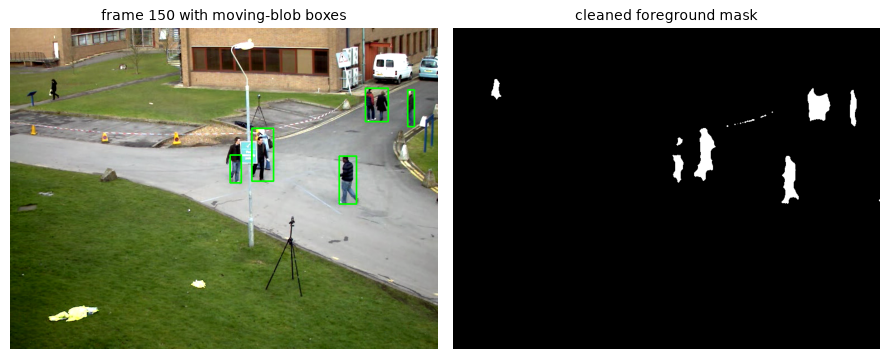

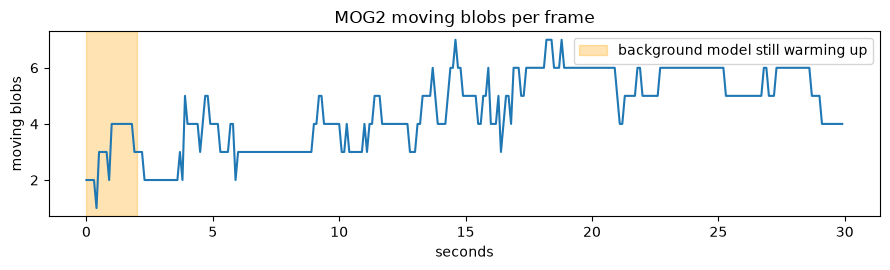

In [34]:
cap = cv2.VideoCapture(str(fetch("vtest.avi")))
if not cap.isOpened():
    raise RuntimeError("could not open vtest.avi — this OpenCV build may lack a video backend")
fps = cap.get(cv2.CAP_PROP_FPS)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fw, fh = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"vtest.avi: {n_frames} frames at {fps:.0f} fps = {n_frames / fps:.0f} s of {fw}×{fh} video")

subtractor = cv2.createBackgroundSubtractorMOG2(history=200, varThreshold=25, detectShadows=True)
video_out = OUTPUT_DIR / "vtest_motion.mp4"
writer = cv2.VideoWriter(str(video_out), cv2.VideoWriter_fourcc(*"mp4v"), fps, (fw, fh))
blob_counts, snapshot = [], None
open3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
close15 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
start = time.perf_counter()
for idx in range(300):                                     # the first 30 seconds
    ok, frame = cap.read()
    if not ok:
        break
    fg = subtractor.apply(frame)
    fg = np.where(fg == 255, 255, 0).astype(np.uint8)       # 127 = shadow → background
    fg = cv2.morphologyEx(cv2.morphologyEx(fg, cv2.MORPH_OPEN, open3), cv2.MORPH_CLOSE, close15)
    n, _, st, _ = cv2.connectedComponentsWithStats(fg)
    big = [s for s in st[1:] if s[cv2.CC_STAT_AREA] > 400]
    blob_counts.append(len(big))
    for s in big:
        cv2.rectangle(frame, (int(s[0]), int(s[1])), (int(s[0] + s[2]), int(s[1] + s[3])), (0, 255, 0), 2)
    writer.write(frame)
    if idx == 150:
        snapshot = (frame.copy(), fg.copy())
elapsed = time.perf_counter() - start
cap.release()
writer.release()
print(f"processed {len(blob_counts)} frames in {elapsed:.2f} s → {len(blob_counts) / elapsed:.0f} fps on this CPU")

check_cap = cv2.VideoCapture(str(video_out))
print(f"wrote {video_out} ({video_out.stat().st_size / 1e6:.1f} MB), reads back as {int(check_cap.get(cv2.CAP_PROP_FRAME_COUNT))} frames")
check_cap.release()

show([snapshot[0], snapshot[1]], ["frame 150 with moving-blob boxes", "cleaned foreground mask"], size=4.5)
plt.figure(figsize=(9, 2.8))
plt.plot(np.arange(len(blob_counts)) / fps, blob_counts)
plt.axvspan(0, 20 / fps, color="orange", alpha=0.3, label="background model still warming up")
plt.gca().set(xlabel="seconds", ylabel="moving blobs", title="MOG2 moving blobs per frame")
plt.legend()
plt.tight_layout()
plt.show()

> 💡 **Interview angle:** "Detect motion from a fixed CPU-only security camera." — background subtraction (MOG2/KNN) + morphology + connected components, with a warm-up period, shadow handling, and a minimum blob area; move to a small detector (e.g. YOLO) only when you need *what* is moving, not just *that* something moves. Mention frame skipping and downscaling for throughput.

## 14. Classic CV vs Deep Learning 🟡

Deep learning (CNNs, vision transformers) dominates **recognition** — "is this a dog?", "segment every car" — because hand-written rules cannot capture the variety of the real world. But classic CV still wins in many real jobs:

| Situation | Classic CV wins because… | Example |
|---|---|---|
| **Controlled environment** (fixed camera, lighting, background) | a few thresholds are enough and never "hallucinate" | counting parts on a conveyor, fill-level checks |
| **Geometry, not semantics** | homographies, calibration, epipolar geometry are exact math | document rectification, panorama stitching, AR marker tracking, camera calibration |
| **No labeled data** | no training set needed | a one-off measurement tool |
| **Tiny compute / latency budget** | milliseconds on a microcontroller-class CPU | motion detection on an edge camera |
| **Explainability / certification** | every step is inspectable | regulated inspection |
| **Pre- and post-processing for DL** | resizing, color conversion, augmentation, NMS | every detection pipeline |

Deep learning wins when appearance varies a lot (lighting, viewpoint, clutter, many classes), when "what" matters more than "where", and when you can collect labels. In practice most production systems are **hybrids**: a learned detector finds the object, classic geometry measures it.

A quick sense of speed — classic operations on a full 768×576 video frame:

In [35]:
frame_gray = cv2.cvtColor(snapshot[0], cv2.COLOR_BGR2GRAY)
for name, op in [("GaussianBlur 5×5", lambda: cv2.GaussianBlur(frame_gray, (5, 5), 0)),
                 ("Canny", lambda: cv2.Canny(frame_gray, 100, 200)),
                 ("adaptiveThreshold", lambda: cv2.adaptiveThreshold(frame_gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2))]:
    start = time.perf_counter()
    for _ in range(100):
        op()
    print(f"{name:18s} {(time.perf_counter() - start) * 10:.3f} ms per frame")

GaussianBlur 5×5   0.056 ms per frame
Canny              0.231 ms per frame
adaptiveThreshold  0.295 ms per frame


> 💡 **Interview angle:** "Would you use deep learning for this?" — ask about variability, data, latency, hardware, and explainability before answering. A strong answer proposes a classic baseline first, measures it on held-out images, and switches to a model only if the baseline fails a stated metric.

## 🔧 Build It From Scratch

Three core algorithms in plain NumPy, each `assert`ed against OpenCV.

### 1) 2-D correlation and convolution with OpenCV's border rule

Pad with `BORDER_REFLECT_101`, take every k×k window with `sliding_window_view`, and take a weighted sum. Then prove that **true convolution = correlation with the kernel flipped**, using SciPy's `convolve` (its `mode="mirror"` is the same border rule).

In [36]:
def correlate2d(img, kernel):
    """Cross-correlation like cv2.filter2D (anchor at the kernel center, BORDER_REFLECT_101)."""
    kh, kw = kernel.shape
    padded = cv2.copyMakeBorder(img.astype(np.float64), kh // 2, kh // 2, kw // 2, kw // 2, cv2.BORDER_REFLECT_101)
    windows = sliding_window_view(padded, (kh, kw))                 # shape (H, W, kh, kw), no copy
    return np.einsum("ijkl,kl->ij", windows, kernel)


test_img = sudoku_gray.astype(np.float64)
random_kernel = rng.normal(size=(5, 5))                              # asymmetric on purpose
ours = correlate2d(test_img, random_kernel)
assert np.allclose(ours, cv2.filter2D(test_img, -1, random_kernel))
assert np.allclose(correlate2d(test_img, random_kernel[::-1, ::-1]), ndi.convolve(test_img, random_kernel, mode="mirror"))
print("✅ correlate2d matches cv2.filter2D, and flipped-kernel correlation matches true convolution")

✅ correlate2d matches cv2.filter2D, and flipped-kernel correlation matches true convolution


### 2) Gaussian blur from the formula

A 1-D Gaussian kernel is $g(x) \propto e^{-x^2 / 2\sigma^2}$ for $x = -(k-1)/2 \ldots (k-1)/2$, normalized to sum to 1. The 2-D kernel is the **outer product** of two 1-D kernels — which is why it is separable.

In [37]:
def gaussian_kernel_1d(ksize, sigma):
    x = np.arange(ksize) - (ksize - 1) / 2
    g = np.exp(-x ** 2 / (2 * sigma ** 2))
    return g / g.sum()


k1 = gaussian_kernel_1d(7, 1.5)
assert np.allclose(k1, cv2.getGaussianKernel(7, 1.5).ravel())
our_blur = correlate2d(test_img, np.outer(k1, k1))
assert np.allclose(our_blur, cv2.GaussianBlur(test_img, (7, 7), 1.5))
assert np.allclose(our_blur, cv2.sepFilter2D(test_img, -1, k1, k1))           # rows then columns
uint8_diff = np.abs(cv2.GaussianBlur(sudoku_gray, (7, 7), 1.5).astype(int) - np.round(our_blur)).max()
print("✅ Gaussian kernel, 2-D blur, and separable blur all match OpenCV (float64)")
print(f"   on uint8 input OpenCV uses fixed-point math: max difference {uint8_diff:.0f} gray level")

✅ Gaussian kernel, 2-D blur, and separable blur all match OpenCV (float64)
   on uint8 input OpenCV uses fixed-point math: max difference 1 gray level


### 3) Sobel gradients and Otsu's threshold

**Otsu** tries every threshold t. Pixels ≤ t form class 0 (probability $\omega_0$, mean $\mu_0$), the rest class 1. It picks the t maximizing the between-class variance $\sigma_B^2(t) = \omega_0 \omega_1 (\mu_0 - \mu_1)^2$, which can be computed for all t at once from cumulative sums of the histogram: with $\omega(t) = \sum_{i \le t} p_i$, $\mu(t) = \sum_{i \le t} i\,p_i$ and total mean $\mu_T$, $\sigma_B^2(t) = \dfrac{(\mu_T\,\omega(t) - \mu(t))^2}{\omega(t)\,(1-\omega(t))}$.

In [38]:
SOBEL_X = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], np.float64)
SOBEL_Y = SOBEL_X.T
assert np.array_equal(correlate2d(test_img, SOBEL_X), cv2.Sobel(test_img, cv2.CV_64F, 1, 0, ksize=3))
assert np.array_equal(correlate2d(test_img, SOBEL_Y), cv2.Sobel(test_img, cv2.CV_64F, 0, 1, ksize=3))
print("✅ Sobel x and y match cv2.Sobel exactly")


def otsu_threshold(img):
    p = np.bincount(img.ravel(), minlength=256) / img.size
    omega = np.cumsum(p)                                   # probability of class 0 for each t
    mu = np.cumsum(p * np.arange(256))                     # cumulative mean
    mu_total = mu[-1]
    with np.errstate(divide="ignore", invalid="ignore"):
        between = (mu_total * omega - mu) ** 2 / (omega * (1 - omega))
    return int(np.argmax(np.nan_to_num(between)))


for name, img in [("sudoku", sudoku_gray), ("smarties saturation", S), ("box", box_gray), ("flower", clean)]:
    cv_T, _ = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    assert otsu_threshold(img) == int(cv_T), name
    print(f"✅ Otsu on {name:20s}: ours = {otsu_threshold(img):3d}, OpenCV = {cv_T:.0f}")

✅ Sobel x and y match cv2.Sobel exactly
✅ Otsu on sudoku              : ours =  97, OpenCV = 97
✅ Otsu on smarties saturation : ours = 116, OpenCV = 116
✅ Otsu on box                 : ours = 118, OpenCV = 118
✅ Otsu on flower              : ours = 100, OpenCV = 100


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Showing a BGR image with Matplotlib

`plt.imshow` expects RGB. Hand it OpenCV's BGR array and red candies appear **blue**. The same bug silently hurts pretrained models that expect RGB input.

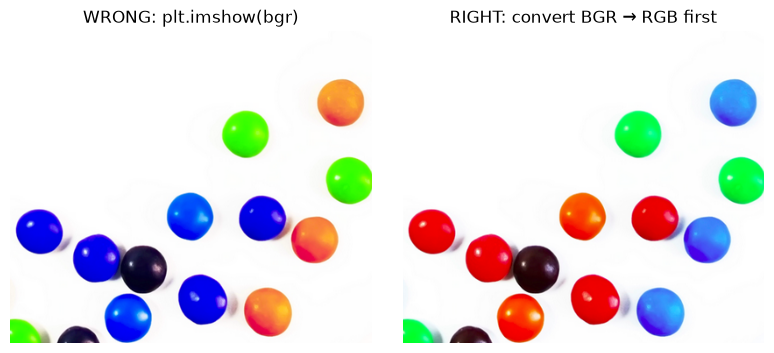

the red candy pixel as Matplotlib reads it (R, G, B): [  0   0 240] → pure blue ❌
after conversion                              (R, G, B): [240   0   0] → red ✅


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].imshow(smarties)                                            # ❌ BGR interpreted as RGB
axes[0].set_title("WRONG: plt.imshow(bgr)")
axes[1].imshow(cv2.cvtColor(smarties, cv2.COLOR_BGR2RGB))           # ✅ convert first
axes[1].set_title("RIGHT: convert BGR → RGB first")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()
print("the red candy pixel as Matplotlib reads it (R, G, B):", smarties[229, 33], "→ pure blue ❌")
print("after conversion                              (R, G, B):", cv2.cvtColor(smarties, cv2.COLOR_BGR2RGB)[229, 33], "→ red ✅")

### ❌ Pitfall 2 — `cv2.imread` returns `None` instead of raising

A typo in the path gives `None`, and the crash happens later with a confusing message. (We lower OpenCV's C++ log level first so its own warning doesn't clutter the output.)

In [40]:
cv2.utils.logging.setLogLevel(cv2.utils.logging.LOG_LEVEL_ERROR)
img = cv2.imread(str(DATA_DIR / "smartie.png"))                     # ❌ typo: missing "s"
print("❌ imread result:", img)
try:
    img.shape
except AttributeError as err:
    print("   …crashes later:", err)


def imread_or_raise(path, flags=cv2.IMREAD_COLOR):                  # ✅ fail loudly, right away
    image = cv2.imread(str(path), flags)
    if image is None:
        raise FileNotFoundError(f"could not read image: {path}")
    return image


try:
    imread_or_raise(DATA_DIR / "smartie.png")
except FileNotFoundError as err:
    print("✅", err)

❌ imread result: None
   …crashes later: 'NoneType' object has no attribute 'shape'
✅ could not read image: _outputs/opencv_samples/smartie.png


### ❌ Pitfall 3 — `uint8` arithmetic wraps around

NumPy arithmetic on `uint8` wraps modulo 256 (250 + 10 = 4). OpenCV's `cv2.add`/`cv2.subtract` **saturate** (clip to 0…255).

❌ NumPy +: 85.5% of values got DARKER when we added brightness
✅ cv2.add: 0.0% got darker


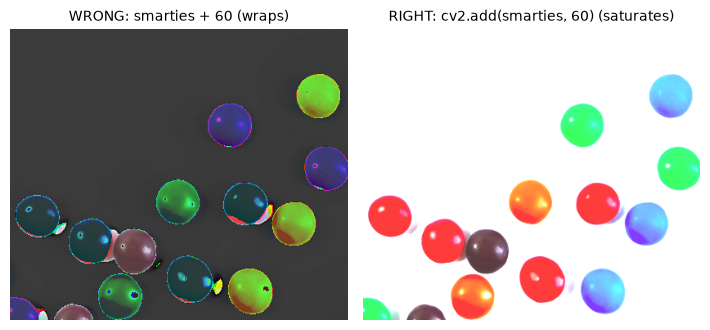

In [41]:
brighten = np.full_like(smarties, 60)
wrapped_img = smarties + brighten                                   # ❌ white 255 + 60 → 59 (dark!)
saturated_img = cv2.add(smarties, brighten)                         # ✅ 255 + 60 → 255
print(f"❌ NumPy +: {(wrapped_img < smarties).mean():.1%} of values got DARKER when we added brightness")
print(f"✅ cv2.add: {(saturated_img < smarties).mean():.1%} got darker")
show([wrapped_img, saturated_img], ["WRONG: smarties + 60 (wraps)", "RIGHT: cv2.add(smarties, 60) (saturates)"], size=3.6)

### ❌ Pitfall 4 — Computing gradients in `uint8`

`cv2.Sobel(img, cv2.CV_8U, …)` clips negative gradients to 0, so you lose every bright→dark edge — half the outline of every object.

In [42]:
g8 = cv2.Sobel(square_img, cv2.CV_8U, 1, 0)                         # ❌ negative values clipped to 0
g_signed = cv2.convertScaleAbs(cv2.Sobel(square_img, cv2.CV_16S, 1, 0))   # ✅ signed, then absolute value
print("❌ CV_8U: edge columns found →", np.unique(np.nonzero(g8)[1]), "(left side only)")
print("✅ CV_16S + convertScaleAbs →", np.unique(np.nonzero(g_signed)[1]), "(both sides)")

❌ CV_8U: edge columns found → [14 15] (left side only)
✅ CV_16S + convertScaleAbs → [14 15 44 45] (both sides)


### ❌ Pitfall 5 — Mixing up `(x, y)` and `[row, col]`

NumPy indexing is `[row, col]` = `[y, x]`, but OpenCV **functions** take points as `(x, y)` and sizes as `(width, height)`.

In [43]:
wrong = cv2.resize(smarties, (smarties.shape[0], smarties.shape[1]))   # ❌ passed (H, W) where (W, H) is expected
right = cv2.resize(smarties, (smarties.shape[1], smarties.shape[0]))   # ✅ (width, height)
print("original", smarties.shape, "| ❌ resize((H, W)) →", wrong.shape, "| ✅ resize((W, H)) →", right.shape)

marked = np.zeros((100, 200), np.uint8)
cv2.circle(marked, (150, 20), 5, 255, -1)                           # center given as (x=150, y=20)
ys_c, xs_c = np.nonzero(marked)
print(f"circle drawn at (x=150, y=20) → pixel mean row {ys_c.mean():.0f}, column {xs_c.mean():.0f} "
      f"→ read it back as marked[20, 150] = {marked[20, 150]}")

original (356, 413, 3) | ❌ resize((H, W)) → (413, 356, 3) | ✅ resize((W, H)) → (356, 413, 3)
circle drawn at (x=150, y=20) → pixel mean row 20, column 150 → read it back as marked[20, 150] = 255


### ❌ Pitfall 6 — Drawing on a crop changes the original

Cropping is slicing, and slices are **views**. Drawing a debug rectangle on a "crop" draws on the original too.

In [44]:
original = smarties.copy()
roi = original[200:260, 0:70]                                        # ❌ a view
cv2.rectangle(roi, (0, 0), (69, 59), (0, 0, 0), 3)
print("❌ original modified:", not np.array_equal(original, smarties))

original = smarties.copy()
roi = original[200:260, 0:70].copy()                                 # ✅ independent copy
cv2.rectangle(roi, (0, 0), (69, 59), (0, 0, 0), 3)
print("✅ original modified:", not np.array_equal(original, smarties))

❌ original modified: True
✅ original modified: False


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Grayscale by hand
Compute `gray_manual` from `smarties` using $Y = 0.299R + 0.587G + 0.114B$ (remember the channel order!), rounded and converted to `uint8`. It must match `cv2.cvtColor` to within 1 gray level.

In [45]:
gray_manual = None  # TODO
check("gray_manual", gray_manual, cv2.cvtColor(smarties, cv2.COLOR_BGR2GRAY), atol=1,
      hint="R is smarties[..., 2] and B is smarties[..., 0]; compute in float, then np.round(...).astype(np.uint8).")

⏳ gray_manual: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
b, g, r = [smarties[..., i].astype(np.float64) for i in range(3)]
gray_manual = np.round(0.299 * r + 0.587 * g + 0.114 * b).astype(np.uint8)
check("gray_manual", gray_manual, cv2.cvtColor(smarties, cv2.COLOR_BGR2GRAY), atol=1)
```
Using `smarties[..., 0]` as R (the RGB habit) gives a visibly wrong image — red candies would look almost black.
</details>

### 🟢 Exercise 2 — Rotate 90° clockwise
Rotate `smarties` 90° clockwise into `rotated`. Its shape should become `(413, 356, 3)`.

In [46]:
rotated = None  # TODO
check("rotated", rotated, np.rot90(smarties, k=-1), hint="cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE) — no interpolation needed.")

⏳ rotated: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
rotated = cv2.rotate(smarties, cv2.ROTATE_90_CLOCKWISE)
check("rotated", rotated, np.rot90(smarties, k=-1))
```
For multiples of 90°, `cv2.rotate` (or `np.rot90`) just rearranges pixels exactly; `warpAffine` would interpolate and blur slightly.
</details>

### 🟢 Exercise 3 — Where does a pixel go after a flip?
Flip `smarties` **left–right** with `cv2.flip` and store in `flip_pixel` the BGR value that now sits at **row 229, column `W − 1 − 33`**, where `W` is the image width.

In [47]:
flip_pixel = None  # TODO
check("flip_pixel", flip_pixel, smarties[229, 33], hint="cv2.flip(img, 1) flips around the vertical axis (left–right); 0 flips up–down.")

⏳ flip_pixel: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
flipped = cv2.flip(smarties, 1)                  # 1 = horizontal flip (mirror left–right)
W = smarties.shape[1]
flip_pixel = flipped[229, W - 1 - 33]
check("flip_pixel", flip_pixel, smarties[229, 33])
```
Mirroring left–right keeps the row and maps column x to W − 1 − x. The same rule is used to flip bounding boxes during data augmentation.
</details>

### 🟡 Exercise 4 — Count the green candies
Using HSV thresholding and connected components on `smarties`, count the **green** candies, including the one cut off by the bottom-left border. Ignore blobs smaller than 300 pixels. Store an `int` in `n_green`.

In [48]:
n_green = None  # TODO
check("n_green", n_green, 3, hint="Green hue is around 60 in OpenCV (range ~45–85); require S and V above ~100; count components with area ≥ 300.")

⏳ n_green: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
hsv_img = cv2.cvtColor(smarties, cv2.COLOR_BGR2HSV)
green_mask = cv2.inRange(hsv_img, (45, 100, 100), (85, 255, 255))
_, _, green_stats, _ = cv2.connectedComponentsWithStats(green_mask)
n_green = int((green_stats[1:, cv2.CC_STAT_AREA] >= 300).sum())
check("n_green", n_green, 3)
```
Skipping label 0 matters: `connectedComponentsWithStats` always reports the background as component 0.
</details>

### 🟡 Exercise 5 — Map a point back through a homography
`H_eye` (section 4) maps the sudoku **photo** to the 450×450 **rectified** grid. The center of grid cell (row 4, col 4) in the rectified image is `(225, 225)`. Where is that point in the original photo? Use the **inverse** homography and `cv2.perspectiveTransform`; store an array of shape `(2,)` with `(x, y)` in `photo_xy`.

In [49]:
photo_xy = None  # TODO
_Hinv = np.linalg.inv(H_eye)
_p = _Hinv @ np.array([225.0, 225.0, 1.0])
check("photo_xy", photo_xy, _p[:2] / _p[2], atol=1e-3,
      hint="cv2.perspectiveTransform expects shape (N, 1, 2) float32: np.float32([[[225, 225]]]); then .reshape(2).")

⏳ photo_xy: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
H_inv = np.linalg.inv(H_eye)
photo_xy = cv2.perspectiveTransform(np.float32([[[225, 225]]]), H_inv).reshape(2)
_Hinv = np.linalg.inv(H_eye)
_p = _Hinv @ np.array([225.0, 225.0, 1.0])
check("photo_xy", photo_xy, _p[:2] / _p[2], atol=1e-3)
```
The checker does the homogeneous math by hand: multiply by $H^{-1}$, then **divide by the third coordinate**. Forgetting that division is the classic homography bug.
</details>

### 🔴 Exercise 6 — Vectorized bilinear sampling (interview classic)
Every resize, rotation, and warp samples the image at non-integer positions. Implement `bilinear_sample(img, xs, ys)` that returns the bilinearly interpolated value of a **float** grayscale image at each `(xs[i], ys[i])` — **no Python loops**. Points are guaranteed to be inside the image with at least one pixel to spare. It must match `cv2.remap(..., cv2.INTER_LINEAR)`.

Bilinear: with $x_0 = \lfloor x \rfloor$, $d_x = x - x_0$ (same for y), the value is $(1-d_x)(1-d_y)I_{00} + d_x(1-d_y)I_{01} + (1-d_x)d_y I_{10} + d_x d_y I_{11}$ where $I_{01}$ is the pixel one step right.

In [50]:
def bilinear_sample(img, xs, ys):
    return None  # TODO


_img = sudoku_gray.astype(np.float32)
_xs = rng.uniform(1, _img.shape[1] - 2, size=500).astype(np.float32)
_ys = rng.uniform(1, _img.shape[0] - 2, size=500).astype(np.float32)
_ref = cv2.remap(_img, _xs.reshape(1, -1), _ys.reshape(1, -1), cv2.INTER_LINEAR).ravel()
check("bilinear_sample", bilinear_sample(_img, _xs, _ys), _ref, atol=1e-2,
      hint="x0 = np.floor(xs).astype(int); dx = xs - x0; gather img[y0, x0], img[y0, x0 + 1], img[y0 + 1, x0], img[y0 + 1, x0 + 1] with fancy indexing.")

⏳ bilinear_sample: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def bilinear_sample(img, xs, ys):
    x0 = np.floor(xs).astype(int)
    y0 = np.floor(ys).astype(int)
    dx, dy = xs - x0, ys - y0
    top = (1 - dx) * img[y0, x0] + dx * img[y0, x0 + 1]
    bottom = (1 - dx) * img[y0 + 1, x0] + dx * img[y0 + 1, x0 + 1]
    return (1 - dy) * top + dy * bottom

_img = sudoku_gray.astype(np.float32)
_xs = rng.uniform(1, _img.shape[1] - 2, size=500).astype(np.float32)
_ys = rng.uniform(1, _img.shape[0] - 2, size=500).astype(np.float32)
_ref = cv2.remap(_img, _xs.reshape(1, -1), _ys.reshape(1, -1), cv2.INTER_LINEAR).ravel()
check("bilinear_sample", bilinear_sample(_img, _xs, _ys), _ref, atol=1e-2)
```
Interpolate along x on the top and bottom rows, then along y between them. Follow-ups interviewers ask: handle borders (clip or reflect indices), and why `cv2.remap` takes a map from *output* to *input* coordinates (backward mapping avoids holes in the output).
</details>

## 🚀 Mini Project: Counting Candies With an Honest Evaluation

**Goal:** build a classic-CV pipeline that finds and counts the candies in OpenCV's real `smarties.png` photo, and measure it **honestly**:

- against **hand-labeled ground truth** (not "number found ÷ number expected", which rewards a detector that finds 14 random points),
- with **one-to-one matching** between detections and true candies, reporting precision, recall, F1, and localization error,
- with parameters chosen on the original image (our *development* image) and then **frozen**, and robustness measured on **held-out perturbed versions** whose ground truth we can transform exactly.

**Steps:** ground truth → matching-based evaluator → three detectors → results on the development image → held-out stress test → conclusions.

### Step 1 — Hand-labeled ground truth

I labeled every candy center by eye on a 3× zoomed copy of the image with a 10-pixel grid, then verified the labels with the overlay below. There are **14 candies**: 12 fully visible and 2 cut off by the bottom border (their label is the center of the *visible* part, flagged `partial`). Label uncertainty is roughly ±3 px. Typical candy radius is ~26 px, so we count a detection as correct if it lies within **13 px** (half a radius) of an unmatched true center.

color
red       4
green     3
blue      3
orange    2
brown     2 
total: 14 | partial: 2


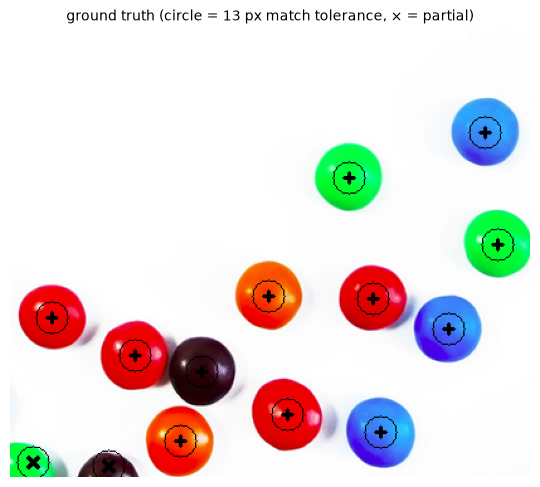

In [51]:
GROUND_TRUTH = pd.DataFrame([
    (33, 229, "red", False), (99, 259, "red", False), (220, 306, "red", False), (288, 214, "red", False),
    (135, 327, "orange", False), (205, 212, "orange", False), (152, 272, "brown", False),
    (269, 118, "green", False), (387, 171, "green", False), (377, 82, "blue", False),
    (348, 238, "blue", False), (294, 320, "blue", False),
    (18, 344, "green", True), (78, 347, "brown", True),
], columns=["x", "y", "color", "partial"])
GT_XY = GROUND_TRUTH[["x", "y"]].to_numpy(np.float64)
MATCH_TOL = 13.0
print(GROUND_TRUTH["color"].value_counts().to_string(), "\ntotal:", len(GROUND_TRUTH), "| partial:", int(GROUND_TRUTH["partial"].sum()))

overlay = smarties.copy()
for (x, y), part in zip(GT_XY.astype(int), GROUND_TRUTH["partial"]):
    cv2.circle(overlay, (int(x), int(y)), int(MATCH_TOL), (0, 0, 0), 1)
    cv2.drawMarker(overlay, (int(x), int(y)), (0, 0, 0), cv2.MARKER_TILTED_CROSS if part else cv2.MARKER_CROSS, 8, 2)
show(overlay, "ground truth (circle = 13 px match tolerance, × = partial)", size=5.5)

### Step 2 — A matching-based evaluator

Each detection may match **at most one** true candy and vice versa. We solve this assignment optimally with the **Hungarian algorithm** (`scipy.optimize.linear_sum_assignment`), forbidding pairs farther apart than the tolerance. Then:

- **TP** (true positive) = matched pairs, **FP** = unmatched detections, **FN** = missed candies
- **precision** = TP / (TP + FP) — "when it says candy, is it right?"; **recall** = TP / (TP + FN) — "does it find them all?"; **F1** = their harmonic mean

In [52]:
def evaluate(pred_xy, gt_xy, tol):
    pred = np.asarray(pred_xy, np.float64).reshape(-1, 2)
    gt = np.asarray(gt_xy, np.float64).reshape(-1, 2)
    tp, errors = 0, []
    if len(pred) and len(gt):
        dist = np.linalg.norm(pred[:, None, :] - gt[None, :, :], axis=2)
        cost = np.where(dist <= tol, dist, 1e6)                  # pairs beyond tolerance are effectively forbidden
        rows_, cols_ = linear_sum_assignment(cost)
        valid = dist[rows_, cols_] <= tol
        tp, errors = int(valid.sum()), dist[rows_, cols_][valid]
    fp, fn = len(pred) - tp, len(gt) - tp
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"found": len(pred), "TP": tp, "FP": fp, "FN": fn, "precision": precision, "recall": recall,
            "F1": f1, "mean_err_px": float(np.mean(errors)) if tp else np.nan}


# Sanity checks of the evaluator itself (a wrong metric makes every later number meaningless)
assert evaluate(GT_XY, GT_XY, MATCH_TOL)["F1"] == 1.0
assert evaluate(GT_XY + 20, GT_XY, MATCH_TOL)["TP"] == 0                         # all shifted too far
assert evaluate(np.repeat(GT_XY[:1], 14, axis=0), GT_XY, MATCH_TOL)["TP"] == 1   # 14 detections on ONE candy = 1 TP
naive_ratio = len(np.repeat(GT_XY[:1], 14, axis=0)) / len(GT_XY)
print(f"✅ evaluator sanity checks pass — note the naive 'found ÷ expected' score for 14 duplicates would be {naive_ratio:.0%}")

✅ evaluator sanity checks pass — note the naive 'found ÷ expected' score for 14 duplicates would be 100%


### Step 3 — Three detectors (parameters picked by looking at the development image)

- **A. Contours** — saturation Otsu mask → open/close → one candy per external contour (centroid). Simple, but touching candies merge.
- **B. Hough circles** — `cv2.HoughCircles` on a blurred grayscale image; votes for circle centers from edge gradients.
- **C. Distance-transform peaks** — fill each blob, compute each pixel's distance to the background (`cv2.distanceTransform`); candy centers are local maxima, even when two candies touch. Nearby peaks are merged.

In [53]:
def candy_mask_from(img):
    s = cv2.GaussianBlur(cv2.cvtColor(img, cv2.COLOR_BGR2HSV)[..., 1], (5, 5), 0)
    _, mask = cv2.threshold(s, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)


def detect_contours(img, min_area=300):
    contours_, _ = cv2.findContours(candy_mask_from(img), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    centers = []
    for c in contours_:
        m = cv2.moments(c)
        if cv2.contourArea(c) >= min_area and m["m00"] > 0:
            centers.append((m["m10"] / m["m00"], m["m01"] / m["m00"]))
    return np.array(centers, np.float64).reshape(-1, 2)


def detect_hough(img):
    blurred_gray = cv2.medianBlur(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 5)
    circles = cv2.HoughCircles(blurred_gray, cv2.HOUGH_GRADIENT, dp=1, minDist=30,
                               param1=100, param2=30, minRadius=18, maxRadius=35)
    return np.empty((0, 2)) if circles is None else circles[0, :, :2].astype(np.float64)


def detect_distance_peaks(img, min_peak=8.0, merge_dist=20.0):
    mask = candy_mask_from(img)
    outer_c, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled = np.zeros_like(mask)
    cv2.drawContours(filled, outer_c, -1, 255, thickness=cv2.FILLED)      # fill specular-highlight holes
    dist = cv2.distanceTransform(filled, cv2.DIST_L2, 5)
    local_max = (dist == cv2.dilate(dist, np.ones((7, 7), np.uint8))) & (dist >= min_peak)
    n_peaks, _, _, peak_xy = cv2.connectedComponentsWithStats(local_max.astype(np.uint8))
    peaks = peak_xy[1:]
    strength = dist[peaks[:, 1].round().astype(int), peaks[:, 0].round().astype(int)]
    kept_peaks = []
    for i in np.argsort(strength)[::-1]:                                    # point NMS: strongest peak wins
        if all(np.linalg.norm(peaks[i] - peaks[j]) > merge_dist for j in kept_peaks):
            kept_peaks.append(i)
    return peaks[kept_peaks].astype(np.float64).reshape(-1, 2)


DETECTORS = {"A contours": detect_contours, "B Hough circles": detect_hough, "C distance peaks": detect_distance_peaks}

### Step 4 — Results on the development image

                  found  TP  FP  FN  precision  recall     F1  mean_err_px     ms
detector                                                                         
A contours           12  11   1   3      0.917   0.786  0.846        0.943  0.618
B Hough circles      12  12   0   2      1.000   0.857  0.923        1.144  1.523
C distance peaks     14  13   1   1      0.929   0.929  0.929        2.598  1.023

recall on the 12 fully visible candies only: {'A contours': 0.75, 'B Hough circles': 1.0, 'C distance peaks': 1.0}


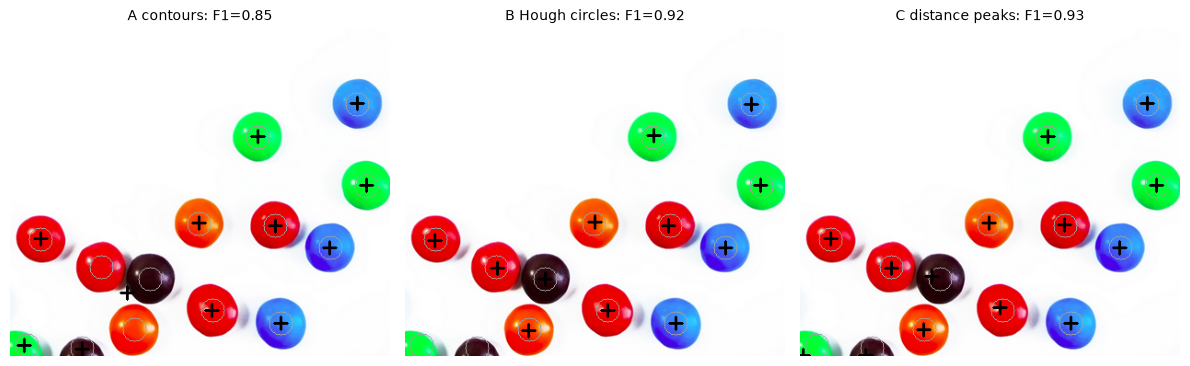

In [54]:
dev_rows, dev_preds = [], {}
for name, detector in DETECTORS.items():
    start = time.perf_counter()
    dev_preds[name] = detector(smarties)
    ms = (time.perf_counter() - start) * 1000
    dev_rows.append({"detector": name, **evaluate(dev_preds[name], GT_XY, MATCH_TOL), "ms": ms})
dev_df = pd.DataFrame(dev_rows).set_index("detector")
print(dev_df.round(3).to_string())

full_mask = ~GROUND_TRUTH["partial"].to_numpy()
print("\nrecall on the 12 fully visible candies only:",
      {n: round(float(evaluate(p, GT_XY[full_mask], MATCH_TOL)["TP"] / full_mask.sum()), 3) for n, p in dev_preds.items()})

panels = []
for name, pred in dev_preds.items():
    canvas = smarties.copy()
    for x, y in GT_XY:
        cv2.circle(canvas, (int(x), int(y)), int(MATCH_TOL), (160, 160, 160), 1)
    for x, y in pred:
        cv2.drawMarker(canvas, (int(round(x)), int(round(y))), (0, 0, 0), cv2.MARKER_CROSS, 14, 2)
    panels.append(canvas)
show(panels, [f"{n}: F1={dev_df.loc[n, 'F1']:.2f}" for n in DETECTORS], size=4)

### Step 5 — Held-out stress test

With only one real photo, we test robustness by changing it in controlled ways the detectors never saw while we picked parameters. Every change has an **exactly known effect on the labels**: lighting, noise, compression, and blur don't move candies; a transpose (rotate 90° + mirror) swaps x and y; downscaling multiplies coordinates (and the tolerance) by the scale factor. Parameters stay **frozen**.

In [55]:
def perturb(img, kind):
    """Return (perturbed image, function mapping ground-truth (x, y) → new coordinates, coordinate scale)."""
    same = (lambda xy: xy)
    if kind == "darker + low contrast":
        return np.clip(img.astype(np.float64) * 0.6 - 30, 0, 255).astype(np.uint8), same, 1.0
    if kind == "uneven lighting":
        ramp = np.linspace(1.0, 0.45, img.shape[1])[None, :, None]              # left bright → right dark
        return np.clip(img * ramp, 0, 255).astype(np.uint8), same, 1.0
    if kind == "Gaussian noise σ=20":
        noise_rng = np.random.default_rng(7)
        return np.clip(img + noise_rng.normal(0, 20, img.shape), 0, 255).astype(np.uint8), same, 1.0
    if kind == "JPEG quality 10":
        _, buf = cv2.imencode(".jpg", img, [cv2.IMWRITE_JPEG_QUALITY, 10])
        return cv2.imdecode(buf, cv2.IMREAD_COLOR), same, 1.0
    if kind == "blur σ=2":
        return cv2.GaussianBlur(img, (0, 0), 2), same, 1.0
    if kind == "transpose (rot 90° + mirror)":
        return np.ascontiguousarray(img.transpose(1, 0, 2)), (lambda xy: xy[:, ::-1]), 1.0
    if kind == "downscale ×0.6":
        s = 0.6
        h_, w_ = img.shape[:2]
        return (cv2.resize(img, (round(w_ * s), round(h_ * s)), interpolation=cv2.INTER_AREA),
                (lambda xy: (xy + 0.5) * s - 0.5), s)                             # pixel-center convention
    raise ValueError(kind)


HELD_OUT = ["darker + low contrast", "uneven lighting", "Gaussian noise σ=20", "JPEG quality 10",
            "blur σ=2", "transpose (rot 90° + mirror)", "downscale ×0.6"]
stress_rows, stress_examples = [], {}
for kind in HELD_OUT:
    img_p, map_gt, scale = perturb(smarties, kind)
    gt_p = map_gt(GT_XY.copy())
    for name, detector in DETECTORS.items():
        pred = detector(img_p)
        stress_rows.append({"condition": kind, "detector": name, **evaluate(pred, gt_p, MATCH_TOL * scale)})
        stress_examples[(kind, name)] = (img_p, gt_p, pred, scale)
stress_df = pd.DataFrame(stress_rows)
print("F1 by condition (rows) and detector (columns):")
f1_table = stress_df.pivot(index="condition", columns="detector", values="F1").loc[HELD_OUT]
print(f1_table.round(3).to_string())
print("\nrecall:")
print(stress_df.pivot(index="condition", columns="detector", values="recall").loc[HELD_OUT].round(3).to_string())

F1 by condition (rows) and detector (columns):
detector                      A contours  B Hough circles  C distance peaks
condition                                                                  
darker + low contrast              0.815            0.923             0.786
uneven lighting                    0.846            0.923             0.929
Gaussian noise σ=20                0.846            0.923             0.929
JPEG quality 10                    0.846            0.923             0.929
blur σ=2                           0.889            0.923             0.929
transpose (rot 90° + mirror)       0.846            0.923             0.929
downscale ×0.6                     0.750            0.000             0.929

recall:
detector                      A contours  B Hough circles  C distance peaks
condition                                                                  
darker + low contrast              0.786            0.857             0.786
uneven lighting                 

### Step 6 — Conclusions (computed, not assumed)

                  dev F1  held-out mean F1  held-out worst F1        worst condition
detector                                                                            
A contours         0.846             0.834              0.750         downscale ×0.6
B Hough circles    0.923             0.791              0.000         downscale ×0.6
C distance peaks   0.929             0.908              0.786  darker + low contrast

• Best on the development image: C distance peaks (F1 0.929).
• Best on held-out conditions   : C distance peaks (mean F1 0.908).
• A contours: drops by 0.096 F1 in its worst condition ('downscale ×0.6').
• B Hough circles: drops by 0.923 F1 in its worst condition ('downscale ×0.6').
• C distance peaks: drops by 0.143 F1 in its worst condition ('darker + low contrast').
• The development ranking held up on the held-out conditions for the top detector.


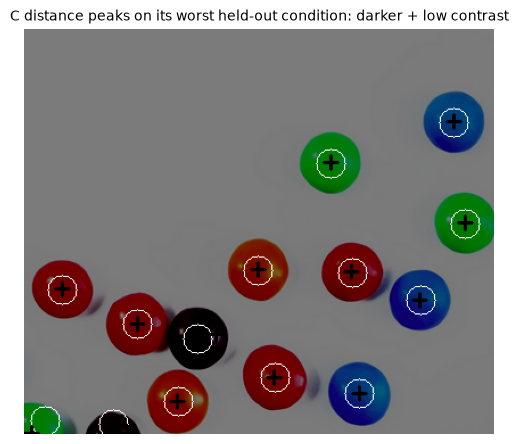

In [56]:
summary = pd.DataFrame({
    "dev F1": dev_df["F1"],
    "held-out mean F1": f1_table.mean(),
    "held-out worst F1": f1_table.min(),
    "worst condition": f1_table.idxmin(),
})
print(summary.round(3).to_string())

best_dev = summary["dev F1"].idxmax()
best_heldout = summary["held-out mean F1"].idxmax()
print(f"\n• Best on the development image: {best_dev} (F1 {summary.loc[best_dev, 'dev F1']:.3f}).")
print(f"• Best on held-out conditions   : {best_heldout} (mean F1 {summary.loc[best_heldout, 'held-out mean F1']:.3f}).")
for name in DETECTORS:
    drop = summary.loc[name, "dev F1"] - summary.loc[name, "held-out worst F1"]
    print(f"• {name}: drops by {drop:.3f} F1 in its worst condition ('{summary.loc[name, 'worst condition']}').")
if best_dev != best_heldout:
    print("• The detector that looked best on the development image is NOT the most robust — "
          "tuning and judging on the same image would have picked the wrong one.")
else:
    print("• The development ranking held up on the held-out conditions for the top detector.")

worst_kind = summary.loc[best_heldout, "worst condition"]
img_p, gt_p, pred, scale = stress_examples[(worst_kind, best_heldout)]
canvas = img_p.copy()
for x, y in gt_p:
    cv2.circle(canvas, (int(round(x)), int(round(y))), int(round(MATCH_TOL * scale)), (255, 255, 255), 1)
for x, y in pred:
    cv2.drawMarker(canvas, (int(round(x)), int(round(y))), (0, 0, 0), cv2.MARKER_CROSS, 12, 2)
show(canvas, f"{best_heldout} on its worst held-out condition: {worst_kind}", size=5)

**Stretch goals**
1. **Classify colors**: for each matched detection, take the median hue/value in a small disk and assign red/orange/brown/green/blue; report per-color accuracy against `GROUND_TRUTH["color"]`.
2. **Make parameters scale-aware**: express radii, kernel sizes, and merge distance as fractions of the estimated candy size (e.g. from the median contour area) and re-run the downscale test.
3. **Watershed**: replace the distance-peak step with `cv2.watershed` seeded by the peaks, and compare the resulting per-candy masks' areas.
4. **Label a second real photo** of candies or coins and use it as a true held-out test image.

### 🗣️ How to talk about this in an interview
- "I built a classic-CV counter — saturation thresholding, morphology, and distance-transform peaks to split touching objects — and compared it with a contour baseline and Hough circles."
- "I evaluated it with **one-to-one Hungarian matching** against hand-labeled centers, reporting precision, recall, F1, and localization error — not 'found ÷ expected', which gives full marks to 14 detections on a single object. I unit-tested the evaluator first."
- "Parameters were chosen on one development image and **frozen**; robustness was measured on held-out perturbations (lighting, noise, JPEG, blur, geometry, scale) where the ground truth transforms exactly."
- "The stress test showed which failure modes matter — for example fixed pixel-size parameters don't transfer across scale — which tells me what to fix or when to switch to a learned detector."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What is convolution in image processing, and how is it related to CNNs?**

<details><summary>Show answer</summary>

- **30-second answer:** A small kernel slides over the image; each output pixel is the weighted sum of the pixels under the kernel. Fixed kernels give blur, sharpening, or Sobel edges; a CNN layer does the same operation but **learns** the kernel weights, and stacks many of them.
- **Go deeper:** Strictly, filtering without flipping is cross-correlation (what `cv2.filter2D` and PyTorch `Conv2d` compute). Borders need a padding rule (reflect, constant, replicate). Separable kernels (Gaussian, Sobel) factor into two 1-D passes: O(k) instead of O(k²) per pixel.
- **❌ Common wrong answer:** "Convolution multiplies the image by the kernel element-wise" — it's a sliding weighted sum, producing one value per position.

</details>

**Q2. Gaussian, median, or bilateral filter — when do you use each?**

<details><summary>Show answer</summary>

- **30-second answer:** Gaussian for general sensor noise before edges/thresholds; median for salt-and-pepper (impulse) noise because outliers don't affect the median; bilateral when you must smooth but keep edges sharp, at a higher compute cost.
- **Go deeper:** Bilateral weights neighbours by both spatial distance and intensity difference, so pixels across an edge barely contribute. For heavy noise with texture, non-local means (`cv2.fastNlMeansDenoising`) is better but slower still. Quantify with PSNR/SSIM on a clean reference, as in section 5.
- **❌ Common wrong answer:** "Always use a Gaussian blur" — it smears salt-and-pepper dots into gray blobs instead of removing them.

</details>

**Q3. Explain the Canny edge detector and how you'd choose its thresholds.**

<details><summary>Show answer</summary>

- **30-second answer:** Gaussian smoothing → Sobel gradient magnitude and direction → non-maximum suppression to thin edges → double thresholding → hysteresis: weak edges are kept only if connected to strong edges. Use a high:low ratio of about 2:1–3:1 and tune on development images, or set them from the median intensity.
- **Go deeper:** Hysteresis is why Canny produces long connected contours with few isolated specks. `L2gradient=True` uses the exact magnitude instead of |Gx|+|Gy|. More blur = fewer, smoother edges.
- **❌ Common wrong answer:** "Canny is just a thresholded Sobel magnitude" — it misses NMS and hysteresis, the two steps that make Canny good.

</details>

**Q4. What does Otsu's method optimize, and when does it fail?**

<details><summary>Show answer</summary>

- **30-second answer:** It picks the single global threshold that maximizes between-class variance (equivalently minimizes within-class variance) of the two pixel groups. It fails when the histogram isn't bimodal — uneven lighting, tiny objects on a huge background, or more than two classes.
- **Go deeper:** It can be computed in O(256) from cumulative histogram sums. For shadows use adaptive thresholding or background normalization; for small objects, compute Otsu on a region of interest.
- **❌ Common wrong answer:** "Otsu adapts the threshold to local lighting" — that's adaptive thresholding; Otsu is global.

</details>

**Q5. What is a homography? How many correspondences do you need, and when is it valid?**

<details><summary>Show answer</summary>

- **30-second answer:** A 3×3 matrix, defined up to scale (8 degrees of freedom), mapping points on one plane to another in homogeneous coordinates. Four point pairs with no three collinear determine it. It is exact for a **planar** scene viewed from any camera, or for any scene when the camera only **rotates** about its center.
- **Go deeper:** Estimate from many noisy matches with DLT inside RANSAC, then refine on inliers. After multiplying, divide by the third coordinate. For non-planar scenes with camera translation you need the fundamental/essential matrix instead.
- **❌ Common wrong answer:** "Three points are enough" (that's affine) or "a homography works for any 3-D scene".

</details>

**Q6. ORB vs SIFT — what's the difference and which would you choose?**

<details><summary>Show answer</summary>

- **30-second answer:** ORB = FAST keypoints + rotated BRIEF binary descriptors (256 bits), matched with Hamming distance — very fast, good for real-time/embedded. SIFT = difference-of-Gaussians keypoints + 128-D gradient-histogram float descriptors matched with L2 — slower, more robust to scale and viewpoint changes.
- **Go deeper:** SIFT's patent expired in March 2020 and it's now in the main OpenCV package (`cv2.SIFT_create`). Use FLANN (LSH index for binary descriptors) for large-scale matching. Learned features (SuperPoint + LightGlue) beat both on hard cases.
- **❌ Common wrong answer:** "Match ORB descriptors with Euclidean distance" — they're bit strings; use `NORM_HAMMING`.

</details>

**Q7. Why does OpenCV use BGR, and where does this cause real bugs?**

<details><summary>Show answer</summary>

- **30-second answer:** Historical: early camera and Windows bitmap formats stored bytes as BGR, and OpenCV kept the convention. Bugs appear when mixing libraries — Matplotlib/PIL/torchvision expect RGB, so colors swap and pretrained models lose accuracy.
- **Go deeper:** Convert exactly once at the boundary (`cv2.cvtColor(img, cv2.COLOR_BGR2RGB)`), and write it in the preprocessing contract shared by training and serving. A model is often fairly robust to swapped channels on *some* classes, which hides the bug until you look at per-class metrics.
- **❌ Common wrong answer:** "It doesn't matter, the network will adapt" — a pretrained network's filters are tuned to the channel order it was trained on.

</details>

### 💻 Coding

**Q8. Implement non-maximum suppression for boxes.**

<details><summary>Show answer</summary>

- **30-second answer:** Sort boxes by score descending; pop the best into `keep`; compute IoU of it with all remaining boxes; drop those above the threshold; repeat until empty (see `nms` in section 11).
- **Go deeper:** Vectorize IoU against all remaining boxes; complexity O(n²) worst case. Run it per class for multi-class detectors (or offset boxes by class id). Soft-NMS decays scores instead of deleting, which helps in crowds. `torchvision.ops.nms` and `cv2.dnn.NMSBoxes` are the library versions.
- **❌ Common wrong answer:** Forgetting to sort by score first, or computing union as `area_a + area_b` without subtracting the intersection.

</details>

**Q9. Count objects in an image where some objects touch each other.**

<details><summary>Show answer</summary>

- **30-second answer:** Segment (threshold/color), clean with morphology, then split touching blobs: distance transform → local maxima as seeds → watershed, or erode until they separate. Count components with a minimum area filter.
- **Go deeper:** Evaluate with one-to-one matching (Hungarian) against labeled centers, reporting precision/recall — the mini project shows contours merge touching objects while distance peaks separate them. For heavy overlap or varied shapes, a detector or instance segmentation model (e.g. Mask R-CNN, YOLO-seg) is more reliable.
- **❌ Common wrong answer:** "Count contours" — touching objects merge into one contour and border-cut objects look like noise.

</details>

**Q10. Rotate an image by an arbitrary angle without cropping the corners.**

<details><summary>Show answer</summary>

- **30-second answer:** Get `M = cv2.getRotationMatrix2D(center, angle, 1)`; compute the new canvas `W' = H|sin| + W|cos|`, `H' = H|cos| + W|sin|`; add `(W'/2 − cx, H'/2 − cy)` to the translation column; `cv2.warpAffine(img, M, (W', H'))`.
- **Go deeper:** Transform bounding boxes/keypoints with the same `M` (for boxes, transform all 4 corners and take the min/max). Choose interpolation: `INTER_NEAREST` for masks. For multiples of 90° use `cv2.rotate` — no interpolation at all.
- **❌ Common wrong answer:** Calling `warpAffine` with the original size (corners are cut off) or passing the size as `(H, W)`.

</details>

### 🐛 Debugging Scenarios

**Q11. Your classifier was 92% accurate in the notebook but 70% in production. Training used PIL; the service uses `cv2.imread`. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** Channel order first (BGR vs RGB), then everything else in preprocessing: resize interpolation and size order `(W, H)`, `uint8` vs float scaling, normalization constants, and JPEG decoding differences. Run the same image through both pipelines and diff the tensors.
- **Go deeper:** Put preprocessing in one shared function used by training and serving, and add a unit test with a golden image and expected tensor checksum. Monitor input statistics (per-channel mean) in production to catch this early.
- **❌ Common wrong answer:** "Retrain on production data" — the bug is a preprocessing mismatch, not data drift.

</details>

**Q12. Your Sobel edge image only shows edges on one side of every object. Why?**

<details><summary>Show answer</summary>

- **30-second answer:** The gradient was computed with `cv2.CV_8U` output, which clips negative derivatives (bright→dark transitions) to 0. Compute in `CV_16S`/`CV_64F`, then `cv2.convertScaleAbs` or take the magnitude.
- **Go deeper:** The opposite bug — casting a signed gradient with `.astype(np.uint8)` — wraps values (−4 → 252) and produces noisy garbage. Also check orientation: `dx=1` responds to vertical edges.
- **❌ Common wrong answer:** "Increase the kernel size" — the problem is the output data type, not the kernel.

</details>

**Q13. Template matching reports 300 matches for an object that appears 4 times. What went wrong?**

<details><summary>Show answer</summary>

- **30-second answer:** Each real match produces a neighbourhood of high scores; you counted every position above the threshold. Apply non-maximum suppression. Also check the template isn't flat (featureless patches match everywhere) and that you used "max is best" methods correctly (`TM_SQDIFF` is "min is best").
- **Go deeper:** Pick the threshold between the weakest true match and the strongest false one on development images (section 11 measures this margin). If the object changes scale/rotation, template matching is the wrong tool — use features or a detector.
- **❌ Common wrong answer:** "Raise the threshold until the count is right" — tuning the threshold to hit a known count on the test image is leakage, and it breaks on the next image.

</details>

### 🏗️ Design

**Q14. A factory wants to detect scratched metal parts on a conveyor. Classic CV or deep learning?**

<details><summary>Show answer</summary>

- **30-second answer:** Start by asking about lighting control, defect variety, labeled data, latency, and false-reject cost. With a fixed camera and controlled lighting, a classic baseline (alignment via template/features, background difference or high-pass filtering, thresholds, morphology, blob size rules) can be built in days and runs in milliseconds; if defects are varied and subtle, move to an anomaly-detection or segmentation model trained on good parts plus a few defects.
- **Go deeper:** Evaluate on held-out production images with precision/recall at the operating point the business needs (missed defect vs wasted good part), monitor drift in lighting, and keep the classic stage as preprocessing (alignment, ROI cropping) even with a model.
- **❌ Common wrong answer:** "Deep learning, always" without asking about data, latency, or the environment — or "classic CV" without planning how to measure it.

</details>

## 🧪 Quick Quiz

Predict the output, then reveal.

**1.** `cv2.imread("does_not_exist.png")`
<details><summary>Answer</summary>

`None` — no exception is raised. Always check the result.
</details>

**2.** `np.array([[250]], np.uint8) + np.array([[10]], np.uint8)` versus `cv2.add` on the same two arrays.
<details><summary>Answer</summary>

NumPy gives `[[4]]` (wraps modulo 256); `cv2.add` gives `[[255]]` (saturates).
</details>

**3.** `cv2.resize(np.zeros((480, 640, 3), np.uint8), (320, 240)).shape`
<details><summary>Answer</summary>

`(240, 320, 3)` — `dsize` is `(width, height)`, while `.shape` is `(height, width, channels)`.
</details>

**4.** What is the OpenCV hue of pure green, `cv2.cvtColor(np.uint8([[[0, 255, 0]]]), cv2.COLOR_BGR2HSV)[0, 0, 0]`?
<details><summary>Answer</summary>

`60` — 120° on the color wheel, halved to fit in `uint8`.
</details>

**5.** Shape of `cv2.matchTemplate` on a 100×100 image with a template of shape `(20, 30)` (height 20, width 30)?
<details><summary>Answer</summary>

`(81, 71)` — `(H − h + 1, W − w + 1)`: one score per position where the template fully fits.
</details>

## 📚 Resources

### 📖 Official Docs
- [Smoothing Images](https://docs.opencv.org/5.0/py_tutorials/py_imgproc/py_filtering/py_filtering.html) — official OpenCV 5.0 Python tutorial on box, Gaussian, median, and bilateral filters
- [Image Thresholding](https://docs.opencv.org/5.0/py_tutorials/py_imgproc/py_thresholding/py_thresholding.html) — global, Otsu, and adaptive thresholding
- [Canny Edge Detection](https://docs.opencv.org/5.0/py_tutorials/py_imgproc/py_canny/py_canny.html) — the algorithm steps and `cv2.Canny` parameters
- [Feature Matching + Homography to find Objects](https://docs.opencv.org/5.0/py_tutorials/py_features/py_feature_homography/py_feature_homography.html) — the ORB/SIFT + ratio test + RANSAC pipeline from section 12
- [opencv/samples/data](https://github.com/opencv/opencv/tree/4.x/samples/data) — the real sample images and video used in this notebook

### 🎥 Videos
- [freeCodeCamp — OpenCV Course - Full Tutorial with Python](https://www.youtube.com/watch?v=oXlwWbU8l2o) (~3 h 40 min) — a slower, hands-on walkthrough of reading images, transforms, thresholding, contours, and more; good if you want a second pass
- [Computerphile — Finding the Edges (Sobel Operator)](https://www.youtube.com/watch?v=uihBwtPIBxM) (~8 min) — Dr Mike Pound explains gradients and why the Sobel kernels look the way they do
- [Computerphile — Canny Edge Detector](https://www.youtube.com/watch?v=sRFM5IEqR2w) (~6 min) — non-maximum suppression and hysteresis with clear drawings

### 📄 Papers
- [Lowe (2004) — Distinctive Image Features from Scale-Invariant Keypoints](https://www.cs.ubc.ca/~lowe/papers/ijcv04.pdf) — the SIFT paper, which also introduced the ratio test used in section 12

### 📘 Books & Courses
- [Szeliski — Computer Vision: Algorithms and Applications, 2nd ed. (free PDF)](https://szeliski.org/Book/) — the standard textbook; chapters 3 (image processing), 7 (features), and 8 (alignment) match this notebook
- [Kaggle Learn — Computer Vision](https://www.kaggle.com/learn/computer-vision) — free short course that bridges into CNNs (next notebook)

### 🏋️ Practice
- [PyImageSearch — How to Build a Kick-Ass Mobile Document Scanner in Just 5 Minutes](https://pyimagesearch.com/2014/09/01/build-kick-ass-mobile-document-scanner-just-5-minutes/) — rebuild the edge → contour → perspective pipeline on your own phone photos

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / rule |
|---|---|---|
| Image = array | pixels as numbers | `(H, W, 3)` `uint8` **BGR**; index `img[y, x]`; points `(x, y)`; sizes `(w, h)` |
| I/O | read/write | `cv2.imread` (check `None`), `imwrite`, `imencode/imdecode`, `IMWRITE_JPEG_QUALITY` |
| Color | change representation | `cvtColor(BGR2RGB/GRAY/HSV)`; H is 0–179; `inRange`; red needs two hue ranges |
| Geometry | move pixels | `resize` (`INTER_AREA` to shrink), `getRotationMatrix2D`+`warpAffine`, `getPerspectiveTransform`+`warpPerspective` |
| Filtering | convolution | `filter2D` (correlation), `blur`, `GaussianBlur`, `medianBlur` (salt & pepper), `bilateralFilter` (keeps edges) |
| Gradients | edges | `Sobel(img, CV_16S/CV_64F, dx, dy)` — `dx=1` ⇒ vertical edges; `convertScaleAbs`; `Canny(low, high)` |
| Thresholding | binary masks | `threshold(…, THRESH_OTSU)`, `adaptiveThreshold` for uneven light |
| Morphology | clean masks | `erode`, `dilate`, `morphologyEx(OPEN/CLOSE)`, `getStructuringElement` |
| Contours | shapes | `findContours(RETR_EXTERNAL, CHAIN_APPROX_SIMPLE)`, `contourArea`, `moments`, `approxPolyDP`; circularity 4πA/P² |
| Histograms | contrast | `calcHist`, `equalizeHist`, `createCLAHE(clipLimit, tileGridSize)` |
| Template matching | find a patch | `matchTemplate(TM_CCOEFF_NORMED)` → threshold → **NMS** (IoU) |
| Features | find an object anywhere | `ORB_create`, `BFMatcher(NORM_HAMMING).knnMatch(k=2)`, ratio 0.75, `findHomography(RANSAC)` |
| Video | frames over time | `VideoCapture`, `read()`, `createBackgroundSubtractorMOG2`, `VideoWriter`, `release()` |
| Evaluation | honest metrics | one-to-one matching (`linear_sum_assignment`) → precision / recall / F1; freeze params, test held-out |

## ➡️ What's Next

**[02 · CNNs and Transfer Learning](02_CNNs_and_Transfer_Learning.ipynb)** — you now know what fixed kernels like Sobel and Gaussian do; a convolutional neural network *learns* thousands of such kernels from data, which is how computers recognize objects that no hand-written rule can describe.